In [2]:
import torch
import numpy as np
import torch.nn as nn
import torchvision.transforms as transforms
import os
from itertools import product
from typing import List, Tuple
from PIL import Image
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score, confusion_matrix, roc_curve, auc
from torch.amp import GradScaler, autocast  # Set device for GPU usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"CUDA Available: {torch.cuda.is_available()}, Device Name: {torch.cuda.get_device_name() if torch.cuda.is_available() else 'None'}")
print(torch.__version__)  # E.g., 2.4.0+cu118
print(torch.cuda.is_available())  # Should print True
from torch.utils.data import random_split
from torch.backends import cudnn
import torch.multiprocessing as mp
mp.set_start_method('spawn', force=True)  
import torch._dynamo  
torch._dynamo.config.suppress_errors = True
torch._dynamo.config.verbose = False        
import time
import random
import logging
logging.getLogger("torch._dynamo").setLevel(logging.ERROR)


Using device: cuda
CUDA Available: True, Device Name: NVIDIA GeForce RTX 4060 Laptop GPU
2.10.0+cu130
True


In [3]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)


In [5]:
torch.backends.cudnn.benchmark = True          # Huge speedup on fixed input size (256×256)
torch.backends.cuda.matmul.allow_tf32 = True   # +15–20% speed on Ampere/Ada (4060)
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision('high')     # Use TensorFloat-32 where possible
os.environ["CUDA_LAUNCH_BLOCKING"] = "0"   

# DATA

In [6]:
# import importlib
# import dataset
# # import testdataset
# importlib.reload(dataset)
# # importlib.reload(testdataset)
# # from traindataset import SignatureVerificationDataset, genuine_extract_path, forgery_extract_path, transform as train_transform
# from dataset import SignatureVerificationDataset, genuine_extract_path, forgery_extract_path


In [7]:
# train_transform = transforms.Compose([
#     transforms.Resize((64, 64)),
#     transforms.Pad(8, fill=255, padding_mode='constant'),
#     transforms.RandomAffine(degrees=8, translate=(0.04, 0.04), scale=(0.92, 1.08), fill=255),
#     transforms.RandomPerspective(distortion_scale=0.1, p=0.25, fill=255),
#     transforms.RandomApply(
#         [transforms.GaussianBlur(3, sigma=(0.1, 0.5))],
#         p=0.3
#     ),
#     transforms.Resize((64, 64)),
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5,)),# <-- randomly erase patches
#     # transforms.RandomErasing(p=0.05, scale=(0.02,0.05), ratio=(0.3,3.3))  
# ])

# test_transform= transforms.Compose([
#     transforms.Resize((64, 64)),  # Resize to match FashionMNIST if needed
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5,))  # Standard normalization
# ])

# class TransformedDataset(Dataset):
#     def __init__(self, base_dataset, transform=None):
#         self.base_dataset = base_dataset
#         self.transform = transform

#     def __len__(self):
#         return len(self.base_dataset)

#     def __getitem__(self, idx):
#         img1, img2, label = self.base_dataset[idx]  # Gets PIL images and label from original
#         if self.transform:
#             img1 = self.transform(img1)
#             img2 = self.transform(img2)
#         return img1, img2, label
        

In [8]:

# all_dataset = SignatureVerificationDataset(
#     genuine_dir=genuine_extract_path,
#     forgery_dir=forgery_extract_path,
#     transform=test_transform
# )
# train_size = int(0.6 * len(all_dataset))
# test_size = len(all_dataset) - train_size
# train_dataset, test_dataset = random_split(all_dataset,[train_size,test_size])


# dataloader = DataLoader(
#     train_dataset, 
#     batch_size=256,           # or 192/256 now that you use 64×64 images
#     shuffle=True,
#     num_workers=8,            # ← magic number for almost all gaming laptops
#     pin_memory=True,          # ← very important with GPU
#     prefetch_factor=2,
#     persistent_workers=True
#                        )
# testdataloader = DataLoader(
#     test_dataset,
#     batch_size=256,           # or 192/256 now that you use 64×64 images
#     shuffle=False,
#     num_workers=6,            # ← magic number for almost all gaming laptops
#     pin_memory=True,          # ← very important with GPU
#     prefetch_factor=2,
#     persistent_workers=True
# )


In [9]:
# from testdataset import SignatureVerificationTestDataset, reference_extract_path, ques_extract_path,transform as test_transform

# testdataset = SignatureVerificationTestDataset(
#     reference_extract_path,
#     ques_extract_path,
#     transform=test_transform
# )
# test_size = int(0.6 * len(testdataset))
# val_size = len(testdataset) - test_size

# test_dataset, val_dataset = random_split(testdataset,[test_size,val_size])

# val_loader = DataLoader(val_dataset,
#                         batch_size=128,           # or 192/256 now that you use 64×64 images
#                         shuffle=False,
#                         num_workers=6,            # ← magic number for almost all gaming laptops
#                         pin_memory=True,          # ← very important with GPU
#                         prefetch_factor=2,
#                         persistent_workers=True
#                        )
# testdataloader = DataLoader(
#     test_dataset,
#     batch_size=128,           # or 192/256 now that you use 64×64 images
#     shuffle=False,
#     num_workers=6,            # ← magic number for almost all gaming laptops
#     pin_memory=True,          # ← very important with GPU
#     prefetch_factor=2,
#     persistent_workers=True
# )

In [10]:
# print(train_transform,"nrdd",test_transform)

Genuine authors: 268, dict_keys(['001', '002', '003', '004', '006', '009', '012', '014', '015', '016', '021', '022', '023', '024', '025', '026', '027', '028', '029', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '052', '053', '054', '055', '056', '057', '058', '059', '060', '061', '068', '069', '070', '071', '072', '073', '074', '075', '076', '077', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '100', '101', '102', '103', '104', '105', '118', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '170', '171', '172', '173', '174', '230', '231', '233', '234', '235', '238', '240', '241', '243', '246', '249', '250', '251', '315', '318', '320', '328', '333', '341', '

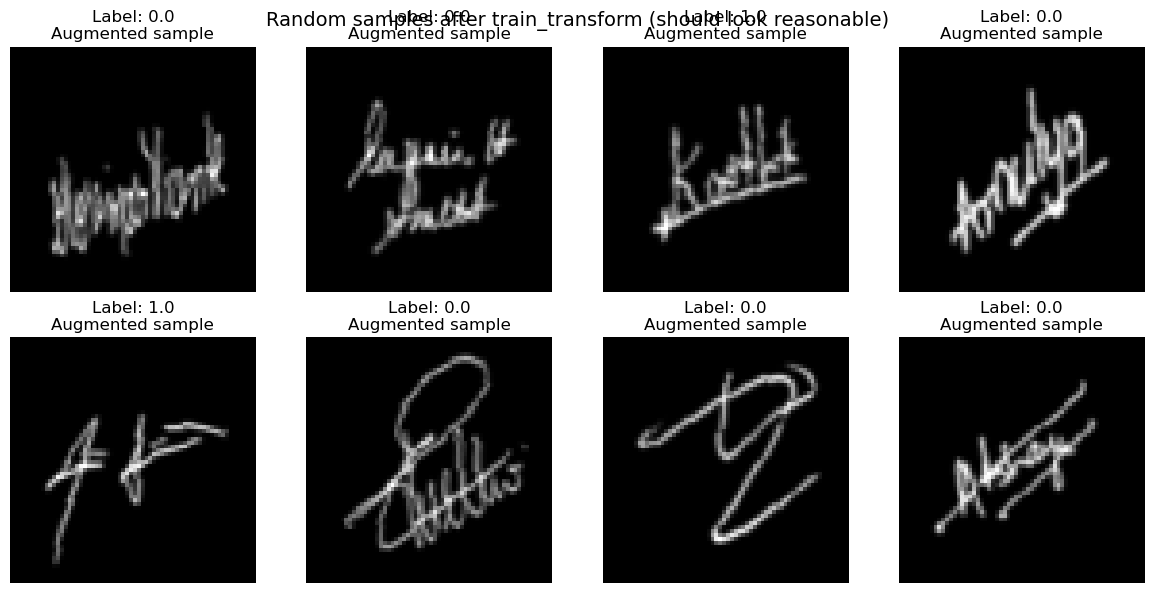

In [16]:
import dataset
import importlib
importlib.reload(dataset)
from dataset import train_dataloader,val_dataloader,test_dataloader


Sample 0 (Label=0.0):
  Img1 - Min: 0.067, Max: 1.000, Mean: 0.942
  Img2 - Min: 0.110, Max: 1.000, Mean: 0.965
  Background (corners): 1.000
  Center (signature): 0.669
  Signature coverage: 12.9%


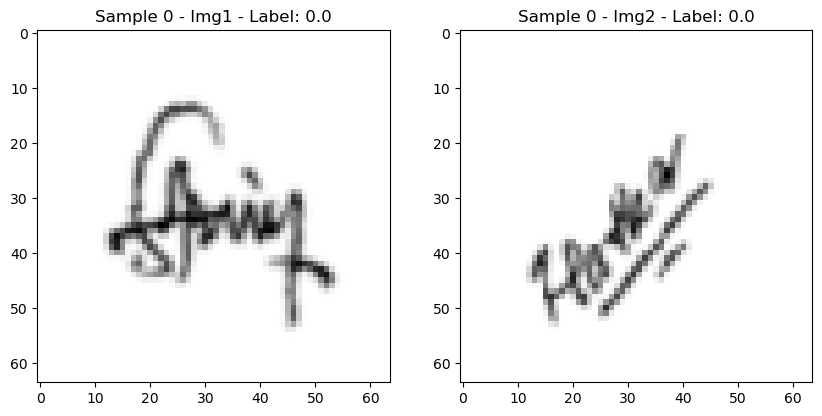


Sample 1 (Label=0.0):
  Img1 - Min: 0.569, Max: 1.000, Mean: 0.987
  Img2 - Min: 0.557, Max: 1.000, Mean: 0.986
  Background (corners): 1.000
  Center (signature): 0.958
  Signature coverage: 5.2%


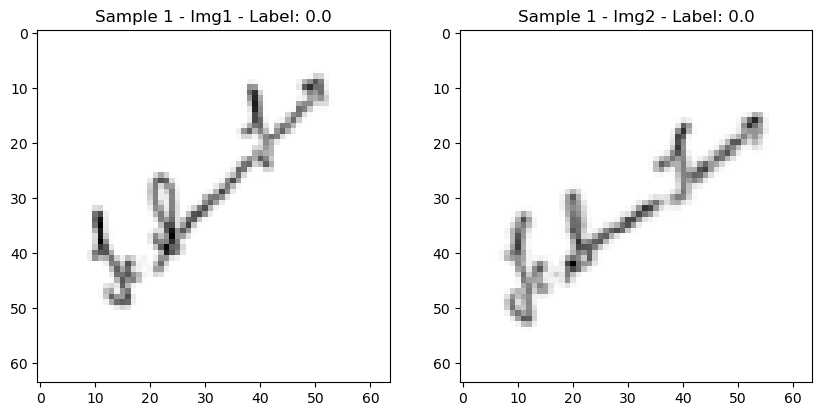


Sample 2 (Label=0.0):
  Img1 - Min: 0.082, Max: 1.000, Mean: 0.935
  Img2 - Min: 0.020, Max: 1.000, Mean: 0.929
  Background (corners): 1.000
  Center (signature): 0.841
  Signature coverage: 15.6%


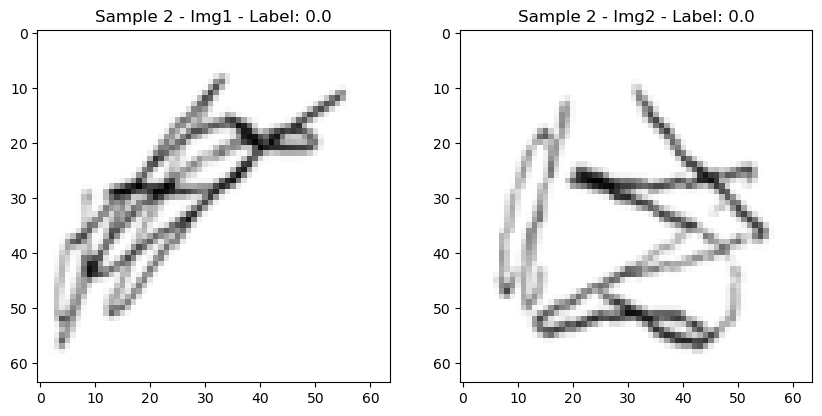


Sample 3 (Label=0.0):
  Img1 - Min: 0.110, Max: 1.000, Mean: 0.930
  Img2 - Min: 0.086, Max: 1.000, Mean: 0.947
  Background (corners): 1.000
  Center (signature): 0.640
  Signature coverage: 16.3%


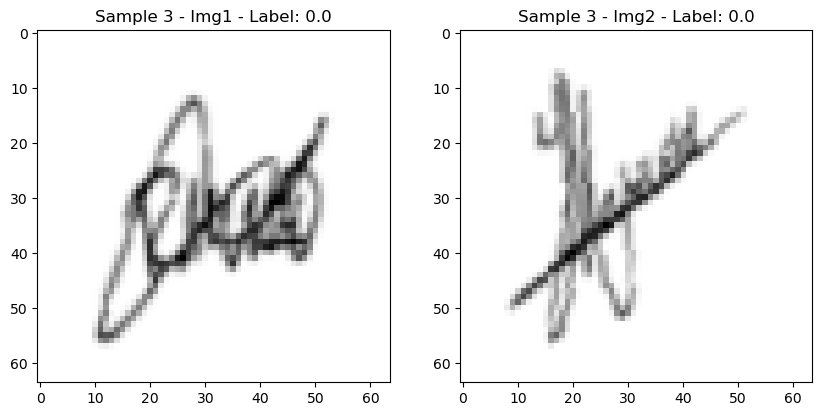


Sample 4 (Label=0.0):
  Img1 - Min: 0.024, Max: 1.000, Mean: 0.931
  Img2 - Min: 0.345, Max: 1.000, Mean: 0.961
  Background (corners): 1.000
  Center (signature): 0.658
  Signature coverage: 14.5%


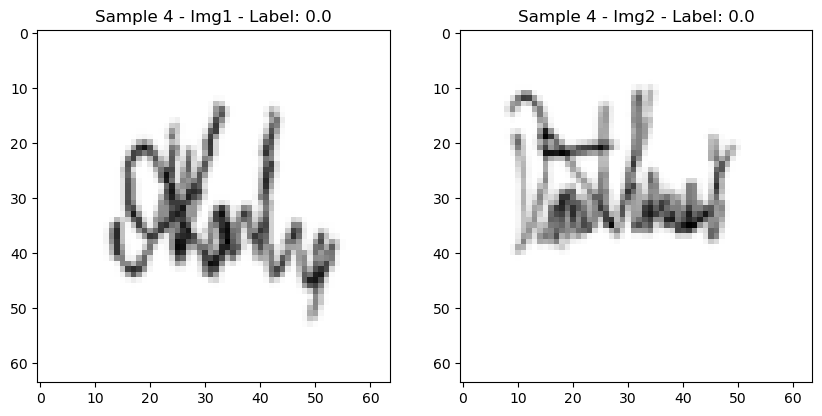


Sample 5 (Label=0.0):
  Img1 - Min: 0.118, Max: 1.000, Mean: 0.952
  Img2 - Min: 0.220, Max: 1.000, Mean: 0.968
  Background (corners): 1.000
  Center (signature): 0.847
  Signature coverage: 11.0%


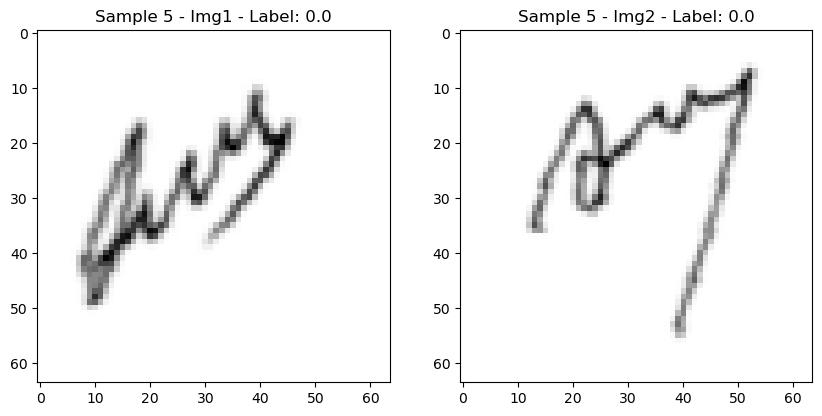


Sample 6 (Label=0.0):
  Img1 - Min: 0.369, Max: 1.000, Mean: 0.975
  Img2 - Min: 0.459, Max: 1.000, Mean: 0.984
  Background (corners): 1.000
  Center (signature): 0.892
  Signature coverage: 8.7%


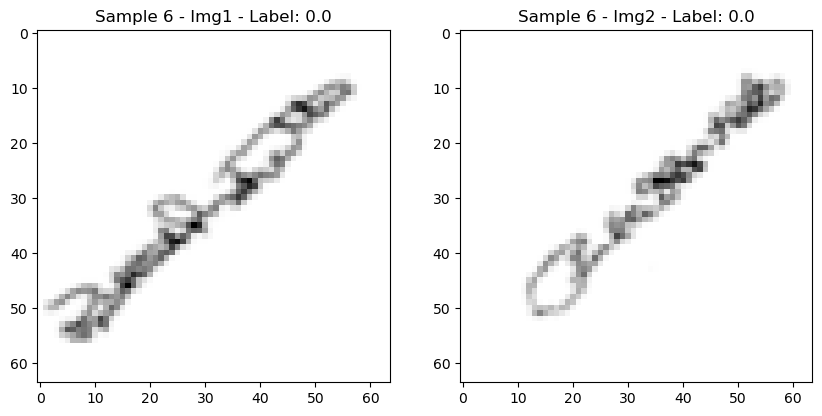


Sample 7 (Label=1.0):
  Img1 - Min: 0.169, Max: 1.000, Mean: 0.942
  Img2 - Min: 0.224, Max: 1.000, Mean: 0.942
  Background (corners): 1.000
  Center (signature): 0.783
  Signature coverage: 18.2%


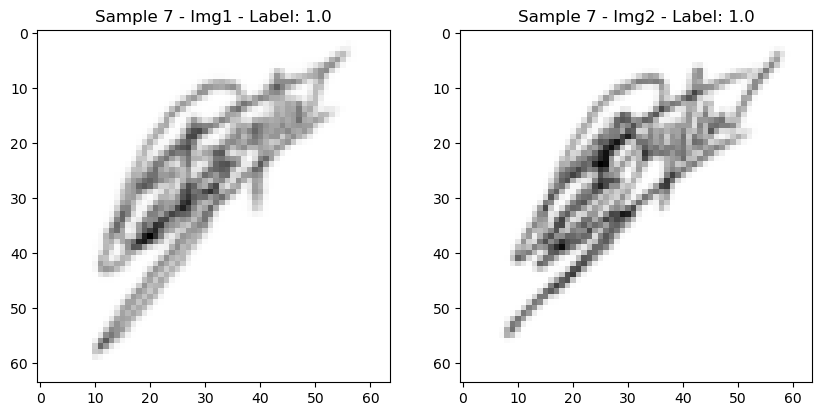


Sample 8 (Label=1.0):
  Img1 - Min: 0.078, Max: 1.000, Mean: 0.934
  Img2 - Min: 0.106, Max: 1.000, Mean: 0.943
  Background (corners): 1.000
  Center (signature): 0.654
  Signature coverage: 18.3%


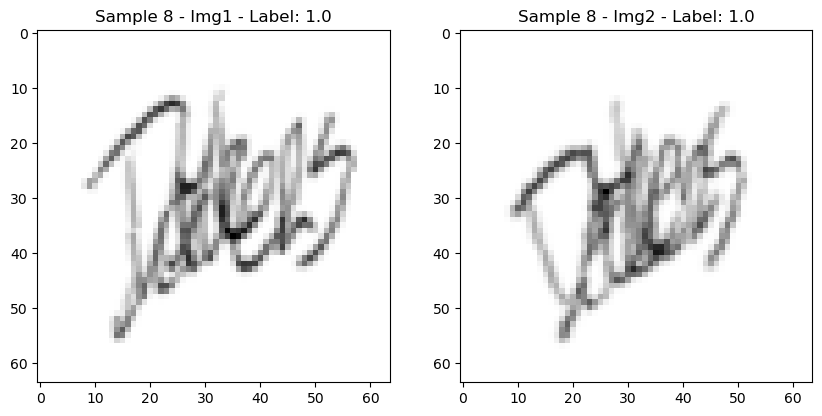


Sample 9 (Label=0.0):
  Img1 - Min: 0.031, Max: 1.000, Mean: 0.933
  Img2 - Min: 0.008, Max: 1.000, Mean: 0.897
  Background (corners): 1.000
  Center (signature): 0.797
  Signature coverage: 15.6%


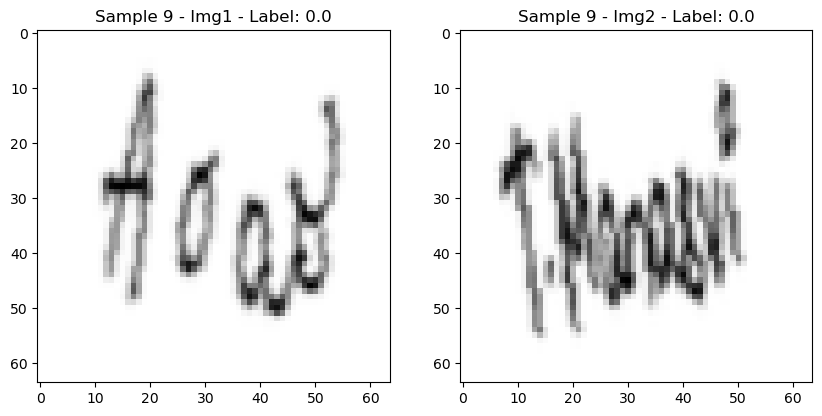

In [16]:
def verify_preprocessing(train_dataloader, num_samples=5):
    """Check if images are properly preprocessed"""
    
    samples_collected = 0
    
    for batch_idx, (img1_array, img2, labels) in enumerate(train_dataloader):
        if isinstance(img1_array, list):
            img1 = img1_array[0]
        else:
            img1 = img1_array
        
        # Iterate through batch
        for i in range(len(img1)):
            if samples_collected >= num_samples:
                return
            
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            
            # Denormalize
            img1_np = (img1[i, 0].cpu().numpy() * 0.5) + 0.5
            img2_np = (img2[i, 0].cpu().numpy() * 0.5) + 0.5
            
            axes[0].imshow(img1_np, cmap='gray')
            axes[0].set_title(f"Sample {samples_collected} - Img1 - Label: {labels[i].item()}")
            axes[1].imshow(img2_np, cmap='gray')
            axes[1].set_title(f"Sample {samples_collected} - Img2 - Label: {labels[i].item()}")
            
            # Check for artifacts
            print(f"\nSample {samples_collected} (Label={labels[i].item()}):")
            print(f"  Img1 - Min: {img1_np.min():.3f}, Max: {img1_np.max():.3f}, Mean: {img1_np.mean():.3f}")
            print(f"  Img2 - Min: {img2_np.min():.3f}, Max: {img2_np.max():.3f}, Mean: {img2_np.mean():.3f}")
            print(f"  Background (corners): {img1_np[0:5, 0:5].mean():.3f}")
            print(f"  Center (signature): {img1_np[25:40, 25:40].mean():.3f}")
            print(f"  Signature coverage: {(img1_np < 0.9).sum() / img1_np.size * 100:.1f}%")
            
            plt.show()
            samples_collected += 1
        
        if samples_collected >= num_samples:
            break

verify_preprocessing(train_dataloader,num_samples=10)

In [ ]:
def check_data_quality(genuine_dir, forgery_dir, num_samples=10):
    """Check if images are clean"""
    import os
    from PIL import Image
    import numpy as np
    
    print("Checking data quality...")
    
    # Check genuine images
    genuine_files = [f for f in os.listdir(genuine_dir) if f.endswith('.png')][:num_samples]
    
    for fname in genuine_files:
        img = Image.open(os.path.join(genuine_dir, fname)).convert('L')
        img_np = np.array(img)
        
        # Check for issues
        white_pixels = (img_np > 250).sum() / img_np.size
        black_pixels = (img_np < 5).sum() / img_np.size
        
        print(f"\n{fname}:")
        print(f"  Size: {img.size}")
        print(f"  White pixels: {white_pixels*100:.1f}%")
        print(f"  Black pixels: {black_pixels*100:.1f}%")
        print(f"  Mean: {img_np.mean():.1f}")
        
        # Should have:
        # - Mostly white background (>70% white)
        # - Some black signature (<30% black)
        if white_pixels < 0.5:
            print("  ⚠️ WARNING: Too much dark area (preprocessing issue?)")
        if black_pixels > 0.5:
            print("  ⚠️ WARNING: Too much black area (inverted?)")

# RUN THIS:
check_data_quality(
    './content/new2/signatures/full_org',
    './content/new2/signatures/full_forg',
    num_samples=5
)

In [ ]:

from dataset import train_transform
# Load a raw signature
test_img = Image.open('./content/new2/signatures/full_forg/forgeries_1_10.png')

# Show before/after preprocessing
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(test_img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

transformed = train_transform(test_img)
axes[1].imshow(transformed.squeeze(), cmap='gray')
axes[1].set_title('After Preprocessing')
axes[1].axis('off')

plt.show()

In [59]:
# class SpatialAttention(nn.Module):
#     def __init__(self, kernel_size=7):
#         super(SpatialAttention, self).__init__()
#         self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2)  # ✅ 2 channels
#         self.sigmoid = nn.Sigmoid()
    
#     def forward(self, x):
#         max_pool = torch.max(x, dim=1, keepdim=True)[0]   # ✅ Max
#         avg_pool = torch.mean(x, dim=1, keepdim=True)     # ✅ Average
#         combined = torch.cat([max_pool, avg_pool], dim=1) # ✅ Concatenate
#         attention = self.sigmoid(self.conv(combined))
        return x * attention
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        # ─── Most important fix ───
        self.conv = nn.Conv2d(1, 1, kernel_size=kernel_size, padding=kernel_size//2)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        # Only max pooling along channel dimension
        max_pool, _ = torch.max(x, dim=1, keepdim=True)   # shape: [B, 1, H, W]
        
        # Now conv receives 1 channel → correct
        attention = self.sigmoid(self.conv(max_pool))     # [B, 1, H, W]
        
        return x * attention

In [60]:
class SiameseCNN(nn.Module):
    def __init__(self):
        super(SiameseCNN, self).__init__()
        
        # Block 1: 64×64 → 64×64 (no pooling!)
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.PReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.PReLU(),
            SpatialAttention(),
            nn.Dropout2d(0.1)
        )
        
        # Block 2: 64×64 → 32×32
        self.pool1 = nn.MaxPool2d(2)
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.PReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.PReLU(),
            SpatialAttention(),
            nn.Dropout2d(0.15)
        )
        
        # Block 3: 32×32 → 16×16
        self.pool2 = nn.MaxPool2d(2)
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.PReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.PReLU(),
            SpatialAttention(),
            nn.Dropout2d(0.2)
        )
        
        # Block 4: 16×16 → 8×8
        self.pool3 = nn.MaxPool2d(2)
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.PReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.PReLU(),
            SpatialAttention(),
            nn.Dropout2d(0.2)
        )
        
        # Global pooling: 8×8 → 1×1
        self.global_pool = nn.AdaptiveMaxPool2d((1, 1))
        
        # Embedding head
        self.embedding = nn.Sequential(
            nn.Linear(256, 256),
            nn.PReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 256)
        )
    
    # ← CRITICAL: These methods must be at the same indentation level as __init__
    def forward_one(self, x):
        """Forward pass for a single image"""
        # Forward through blocks
        x = self.block1(x)      # 64×64×32
        x = self.pool1(x)       # 32×32×32
        
        x = self.block2(x)      # 32×32×64
        x = self.pool2(x)       # 16×16×64
        
        x = self.block3(x)      # 16×16×128
        x = self.pool3(x)       # 8×8×128
        
        x = self.block4(x)      # 8×8×256
        
        x = self.global_pool(x) # 1×1×256
        x = torch.flatten(x, 1) # 256
        
        x = self.embedding(x)   # embedding_dim
        x = F.normalize(x, p=2, dim=1)  # L2 normalize
        return x
    
    def forward(self, x1, x2=None):
        """
        Forward pass for Siamese network
        
        Args:
            x1: First image tensor
            x2: Optional second image tensor
            
        Returns:
            If x2 is None: returns emb1
            If x2 is provided: returns (emb1, emb2)
        """
        emb1 = self.forward_one(x1)
        if x2 is not None:
            emb2 = self.forward_one(x2)
            return emb1, emb2
        return emb1

In [61]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, emb1, emb2, label):
        distance = F.pairwise_distance(emb1, emb2)
        
        # Genuine pairs: minimize distance
        pos_loss = label * torch.pow(distance, 2)
        
        # Forged pairs: maximize distance (up to margin)
        neg_loss = (1 - label) * torch.pow(torch.clamp(self.margin - distance, min=0.0),2)
        loss = pos_loss + neg_loss

        weights = torch.ones_like(loss)
        
        # Hard positives: pairs with large distance
        hard_pos_mask = (label == 1) & (distance > distance[label==1].median())
        weights[hard_pos_mask] = 2.0
        
        # Hard negatives: pairs with small distance
        hard_neg_mask = (label == 0) & (distance < distance[label==0].median())
        weights[hard_neg_mask] = 2.0
        
        loss = loss * weights
    
        return loss.mean()

In [62]:
plt.close('all')  # Close all open figuresos.makedirs('saved_models', exist_ok=True)
margin=0.8
lr=0.01
threshold=0.7
model=SiameseCNN()
model = torch.compile(model, mode="reduce-overhead")   # or "default"
model = model.to(device)

In [63]:
import torch.optim.lr_scheduler as lr_scheduler
criterion = ContrastiveLoss(margin=margin)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)  # AdamW > Adam
scaler = GradScaler()
# After optimizer definition
scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # 'min' for minimizing loss; use 'max' if monitoring accuracy
    factor=0.1,       # Multiply lr by this (e.g., 0.0001 → 0.00001)
    patience=10,
    threshold=1e-4,   # Wait this many epochs without improvement
    min_lr=1e-6 # Optional: Minimum lr to stop reducing below
)
best_model_path = f"second_saved_models/savedmodels/dropoutCNN/best_siamese_margin{margin}_size64_lr{lr}.pt"


In [64]:
# Training with mixed precision
best_val_loss = float('inf')
early_stop_counter = 0
patience = 10
min_delta = 0.0005
num_epochs = 30

for epoch in range(num_epochs):
    # ─── Training ────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    num_batches = 0
    start_time = time.time()

    for img1, img2, labels in train_dataloader:
        img1, img2, labels = (img1.to(device, non_blocking=True),
                              img2.to(device, non_blocking=True),
                              labels.to(device, non_blocking=True))
        optimizer.zero_grad(set_to_none=True)
        with autocast('cuda', dtype=torch.bfloat16):
            emb1 = model(img1)
            emb2 = model(img2)
            loss = criterion(emb1, emb2, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        num_batches += 1

    epoch_time = time.time() - start_time
    avg_train_loss = epoch_loss / num_batches
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch:2d}/{num_epochs} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Time: {epoch_time:.1f}s | "
          f"LR: {current_lr:.6f}")
    

    # ─── Validation every 2 epochs ───────────────────────────────────
    # ─── Validation every 4 epochs ───────────────────────────────────
    if (epoch + 1) % 1 == 0:
        model.eval()
        val_losses = []
        distance_all = []
        labels_all = []
        
        with torch.no_grad():
            for img1, img2, labels in val_dataloader:
                # Use only first reference
                img1 = img1.to(device, non_blocking=True)
                img2 = img2.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
            
                with autocast("cuda", dtype=torch.bfloat16):
                    emb1 = model(img1)
                    emb2 = model(img2)
            
                distance = F.pairwise_distance(emb1, emb2)
                distance_all.append(distance)
                labels_all.append(labels)
            
                val_batch_loss = criterion(emb1, emb2, labels)
                val_losses.append(val_batch_loss.item())

        # Aggregate
        distance_all = torch.cat(distance_all)
        labels_all = torch.cat(labels_all)
        avg_val_loss = sum(val_losses) / len(val_losses)

        # ─── Threshold tuning (FIXED!) ───────────────────────────────
        y_true = labels_all.cpu().numpy()  # ← THIS WAS MISSING!
        
        # Method 1: Simple negation approach (recommended)
        similarity_scores = -distance_all.cpu().numpy()
        fpr, tpr, thresholds_roc = roc_curve(y_true, similarity_scores)
        optimal_idx = np.argmax(tpr - fpr)
        optimal_threshold = -thresholds_roc[optimal_idx]  # Convert back to distance

        eer = fpr[np.nanargmin(np.abs(fpr - (1 - tpr)))]
        print(f"EER: {eer:.4f}")  # Aim for <0.1 for good models
        y_pred = (distance_all.cpu().numpy() < optimal_threshold).astype(int)

        print(f"   Val Loss: {avg_val_loss:.6f} | "
              f"Acc: {accuracy_score(y_true, y_pred):.4f} | "
              f"Threshold: {optimal_threshold:.3f} | "  # ← FIXED variable name
              f"Genuine: {distance_all[labels_all==1].mean():.3f} | "
              f"Forged: {distance_all[labels_all==0].mean():.3f}")
        
        scheduler.step(avg_val_loss)

        # ─── Early Stopping ──────────────────────────────────────────
        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss = avg_val_loss
            early_stop_counter = 0
            torch.save(model.state_dict(), best_model_path)
            print(f"   → New best val loss: {best_val_loss:.6f} (saved)")
        else:
            early_stop_counter += 1
            print(f"   → No improvement. Patience: {early_stop_counter}/{patience}")

        if early_stop_counter >= patience:
            print(f"Early stopping at epoch {epoch}. Best val loss: {best_val_loss:.6f}")
            break

        # Cleanup (FIXED!)
        del distance_all, labels_all, y_true, y_pred
        torch.cuda.empty_cache()

# ─── Load best model ─────────────────────────────────────────────────
print("Loading best model for final evaluation...")
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

Epoch  0/30 | Train Loss: 0.2541 | Time: 70.6s | LR: 0.010000
EER: 0.3492
   Val Loss: 0.334242 | Acc: 0.6658 | Threshold: 0.140 | Genuine: 0.091 | Forged: 0.193
   → New best val loss: 0.334242 (saved)
Epoch  1/30 | Train Loss: 0.2367 | Time: 53.7s | LR: 0.010000
EER: 0.3013
   Val Loss: 0.264834 | Acc: 0.7241 | Threshold: 0.200 | Genuine: 0.110 | Forged: 0.330
   → New best val loss: 0.264834 (saved)
Epoch  2/30 | Train Loss: 0.2151 | Time: 56.1s | LR: 0.010000
EER: 0.2587
   Val Loss: 0.217468 | Acc: 0.7533 | Threshold: 0.262 | Genuine: 0.147 | Forged: 0.447
   → New best val loss: 0.217468 (saved)
Epoch  3/30 | Train Loss: 0.1954 | Time: 55.1s | LR: 0.010000
EER: 0.2371
   Val Loss: 0.205793 | Acc: 0.7673 | Threshold: 0.255 | Genuine: 0.177 | Forged: 0.450
   → New best val loss: 0.205793 (saved)
Epoch  4/30 | Train Loss: 0.1663 | Time: 54.5s | LR: 0.010000
EER: 0.2297
   Val Loss: 0.189704 | Acc: 0.7768 | Threshold: 0.392 | Genuine: 0.253 | Forged: 0.645
   → New best val loss: 0.

OptimizedModule(
  (_orig_mod): SiameseCNN(
    (block1): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): PReLU(num_parameters=1)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): PReLU(num_parameters=1)
      (6): SpatialAttention(
        (conv): Conv2d(2, 1, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
        (sigmoid): Sigmoid()
      )
      (7): Dropout2d(p=0.1, inplace=False)
    )
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (block2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): PReLU(num_parameters=1)
      (3): Co

C:\Users\gupta\7th SEM\Project\Signature\saliency_visualization.py:367: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: manual_analysis/pair_0_genuine pair_dist0.131.png


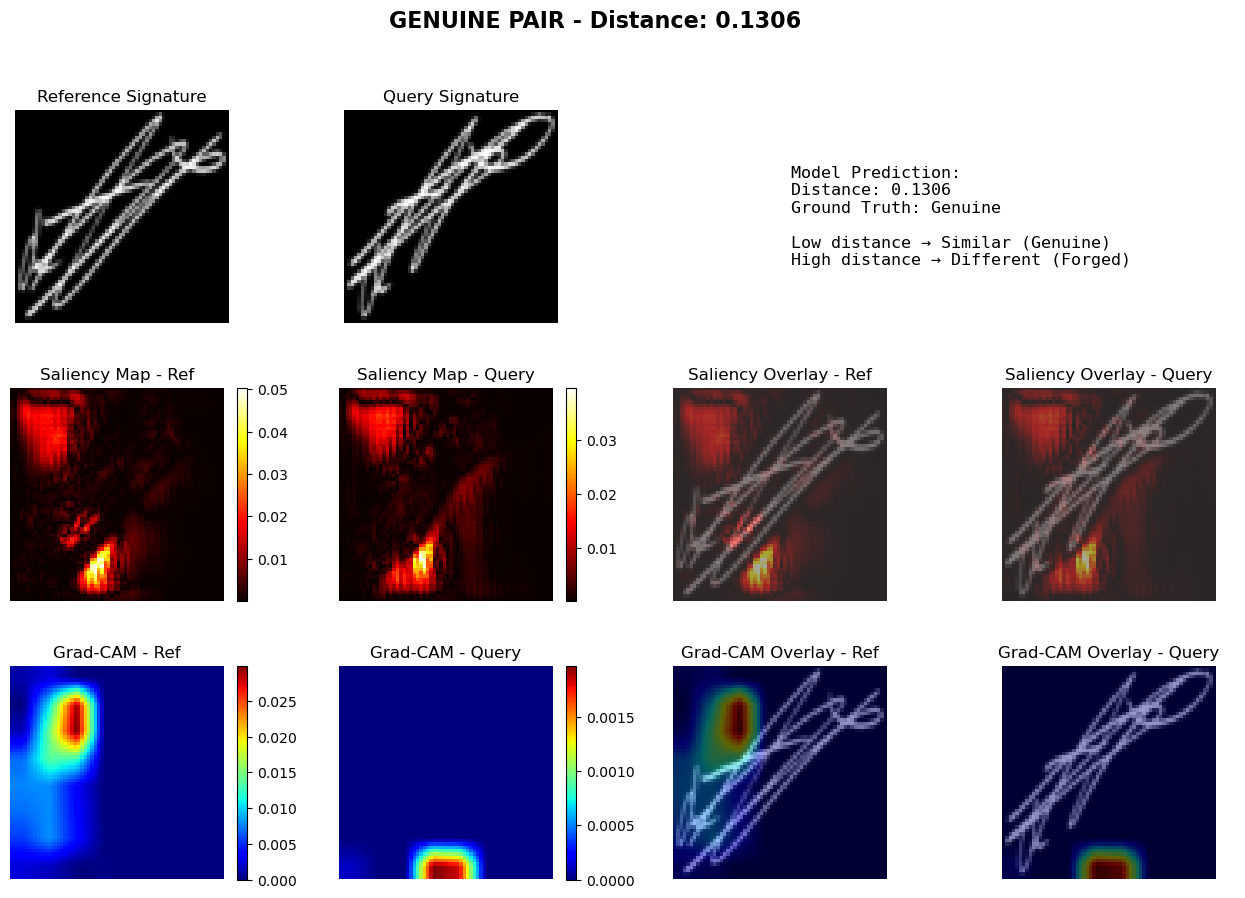

Saved: manual_analysis/pair_1_genuine pair_dist0.145.png


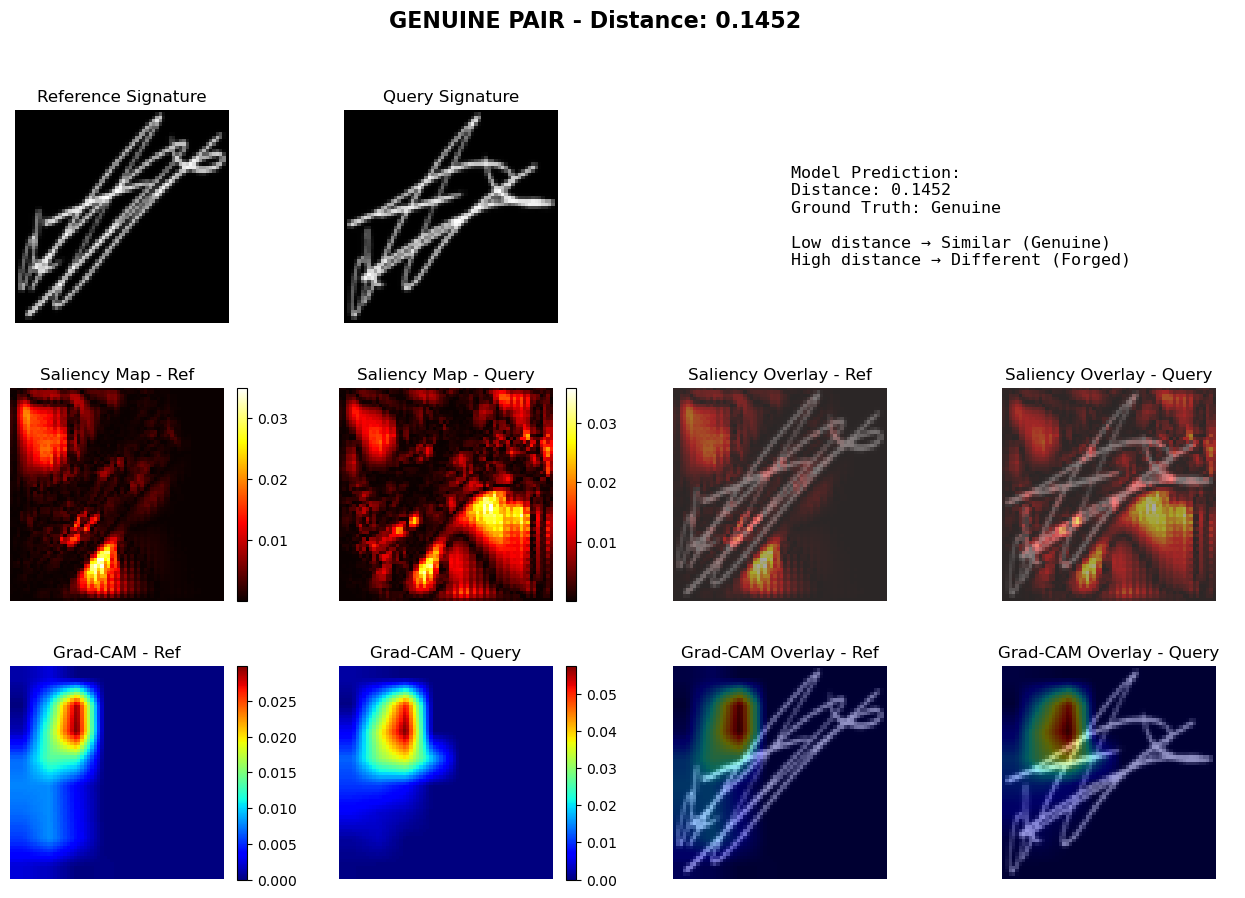

Saved: manual_analysis/pair_2_genuine pair_dist0.233.png


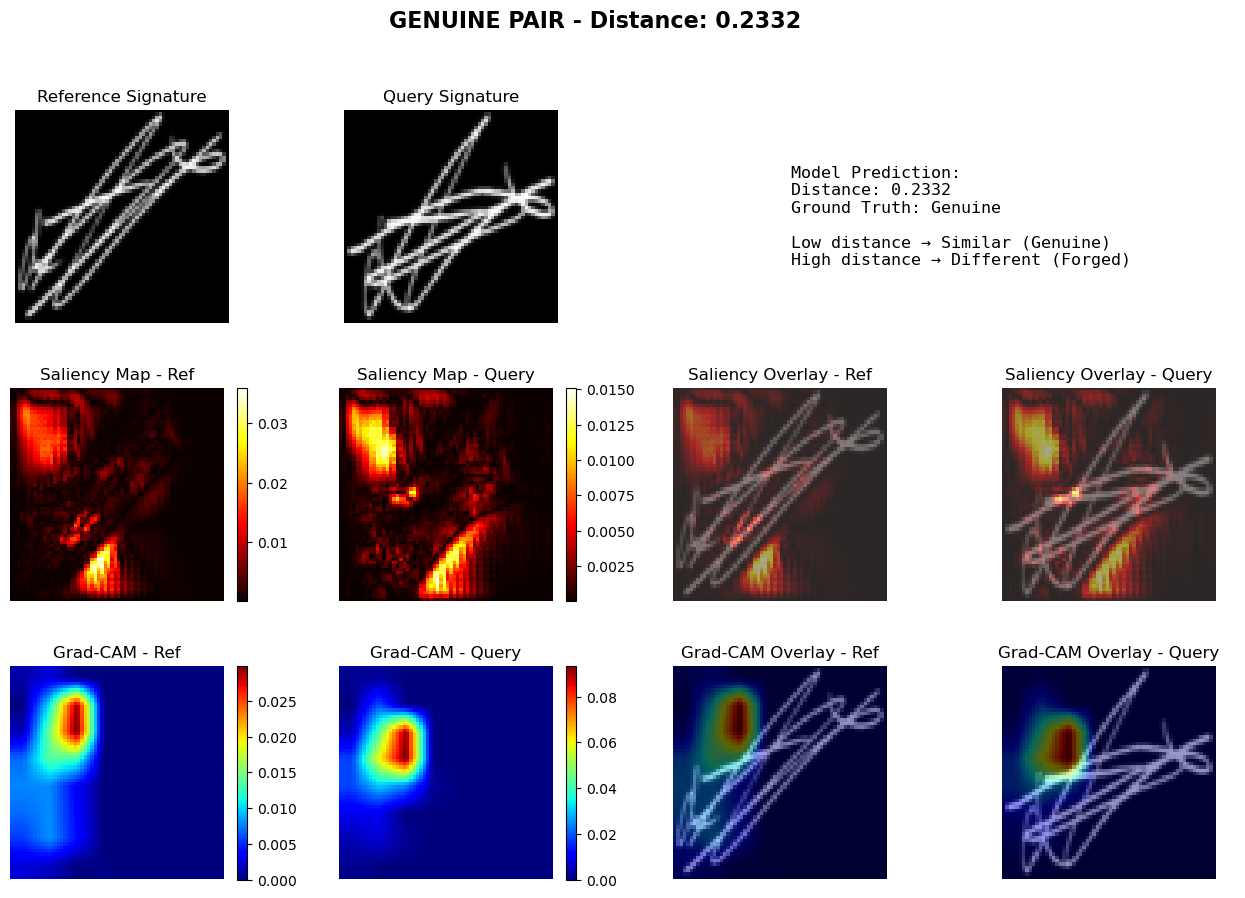

Saved: manual_analysis/pair_3_genuine pair_dist0.076.png


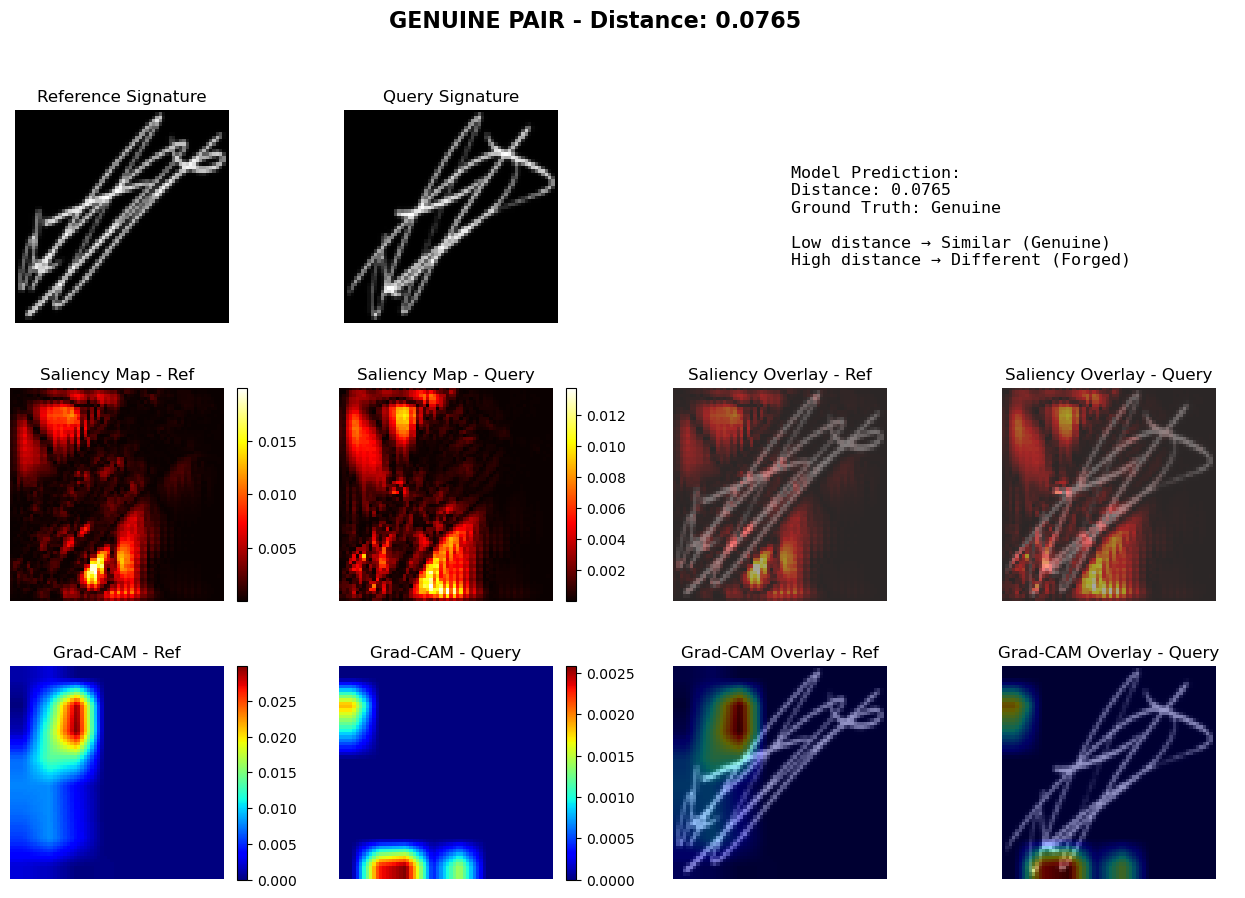

Saved: manual_analysis/pair_4_genuine pair_dist0.051.png


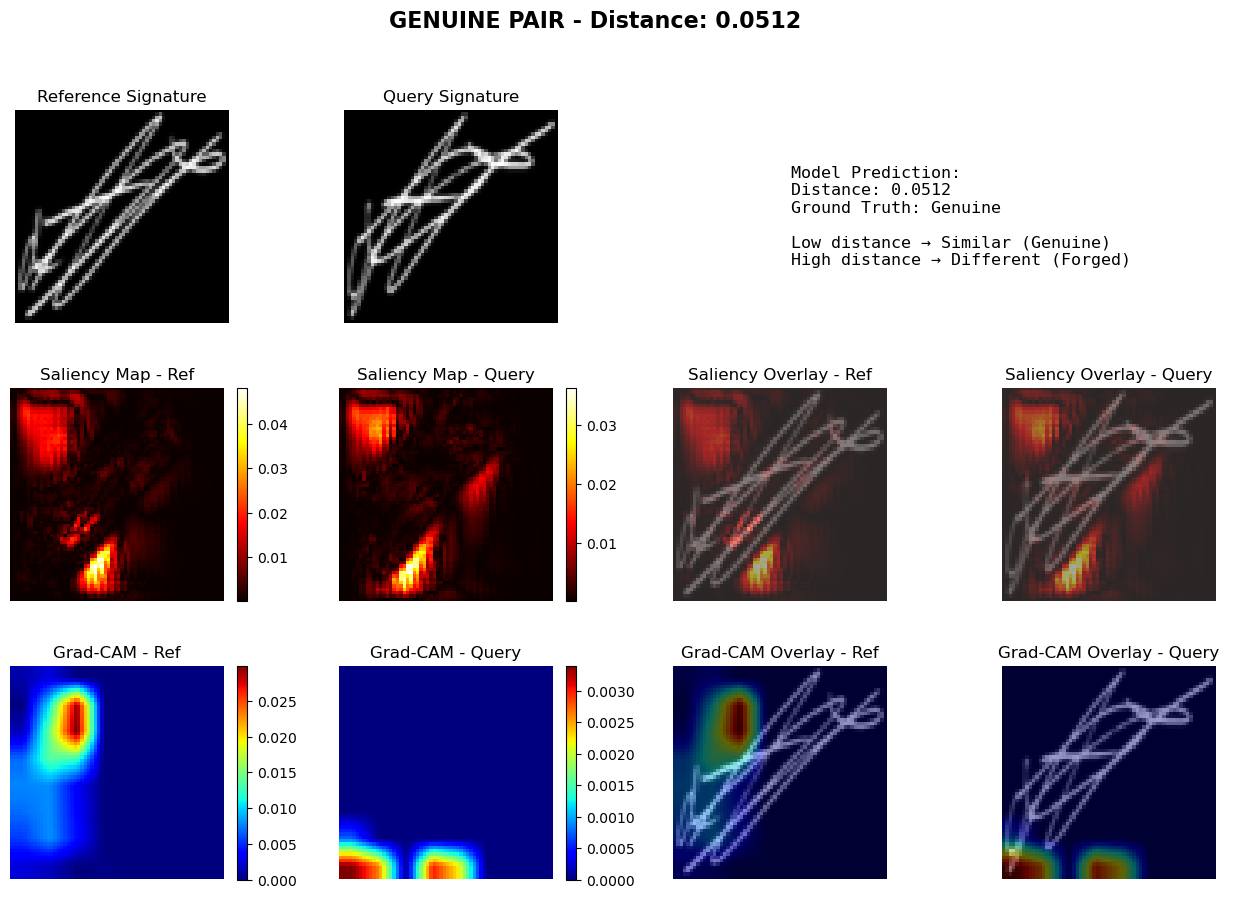

Saved: feature_map_analysis/feature_maps_0.png


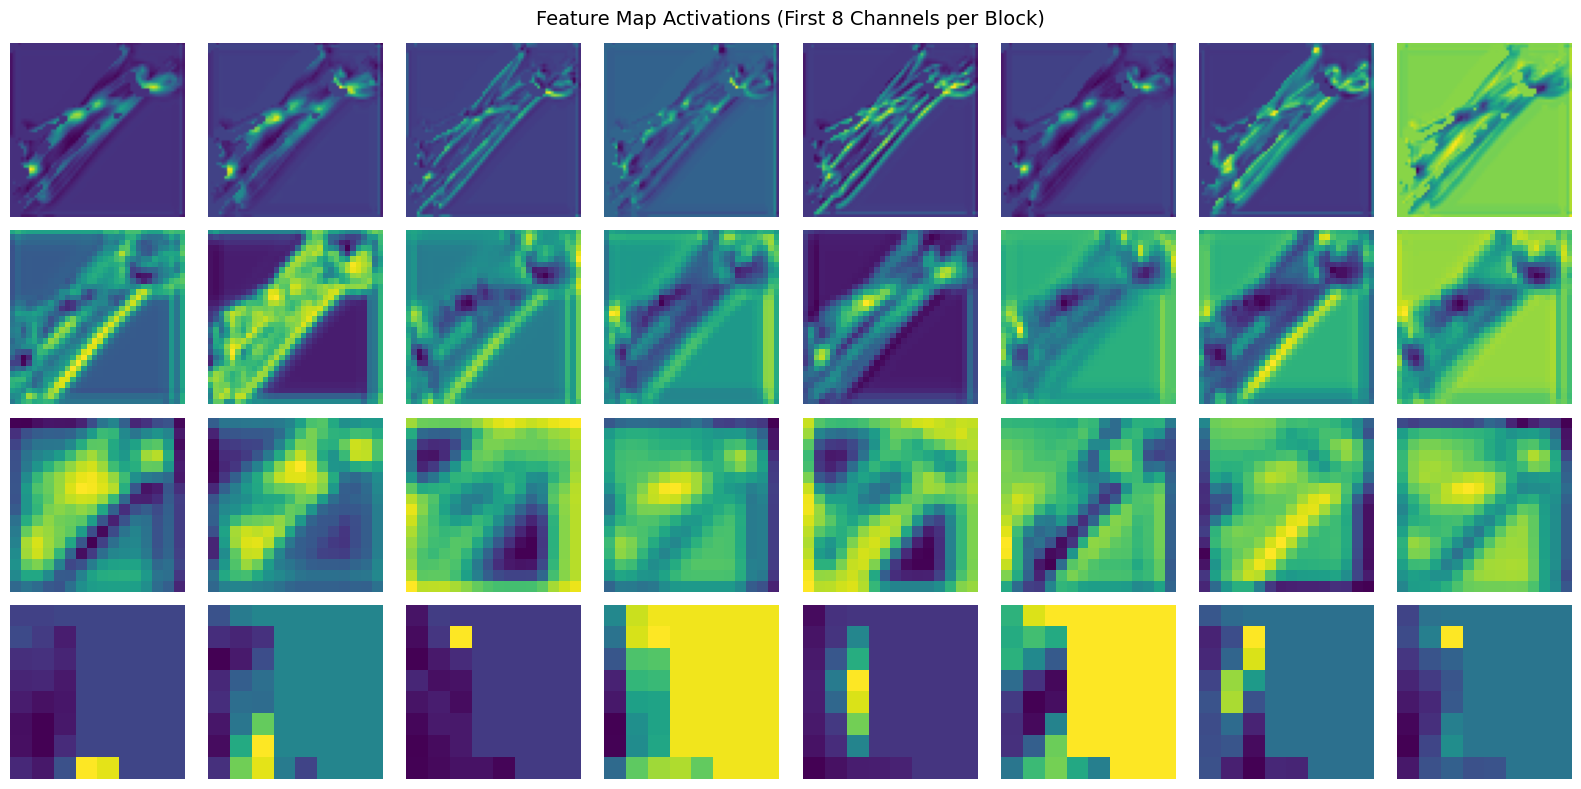


Found 10 confidently wrong predictions
These are the cases where the model is most confused:

Pair 0: True=0.0, Predicted=1.0, Distance=0.3812
Saved: wrong_predictions/pair_0_forged pair_dist0.381.png


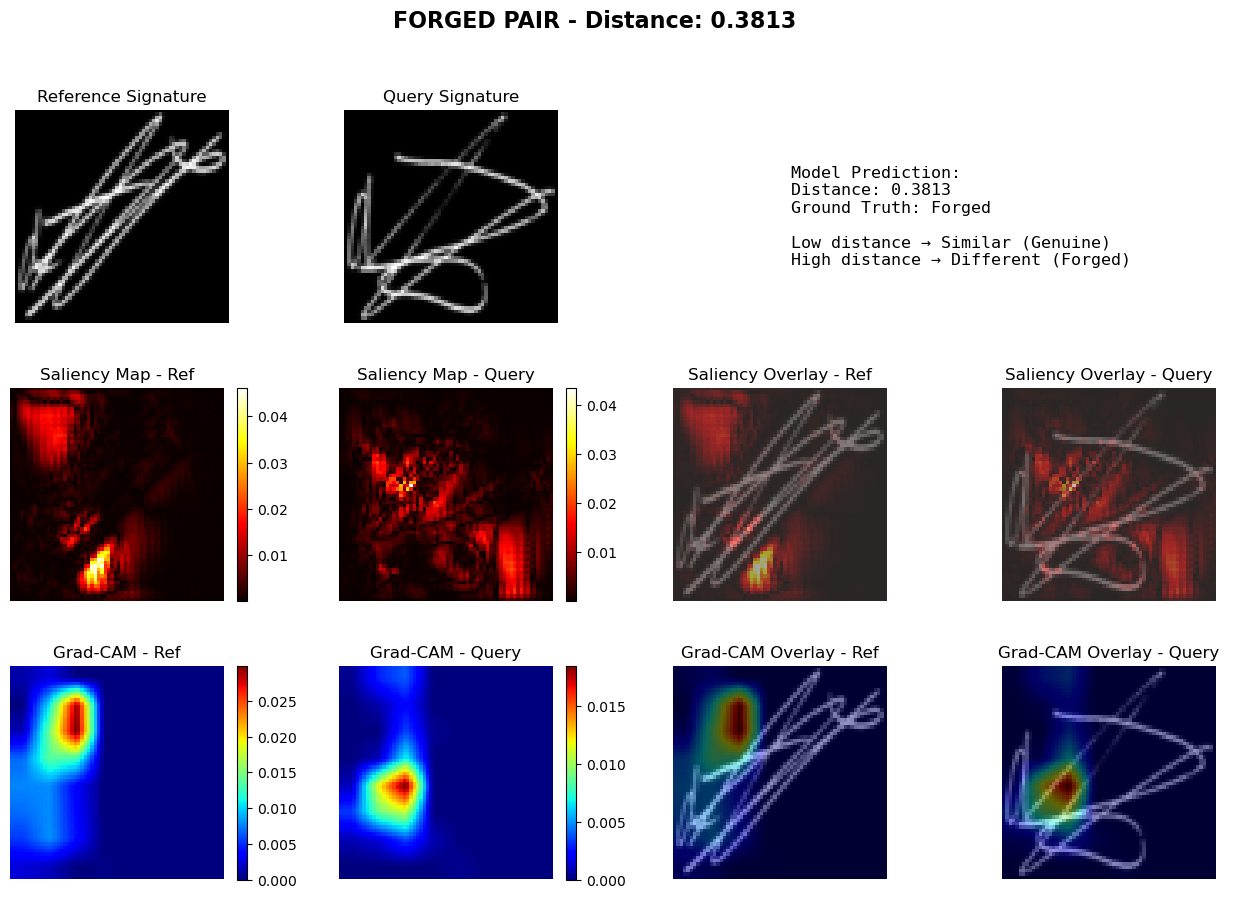


Pair 1: True=0.0, Predicted=1.0, Distance=0.2150
Saved: wrong_predictions/pair_1_forged pair_dist0.215.png


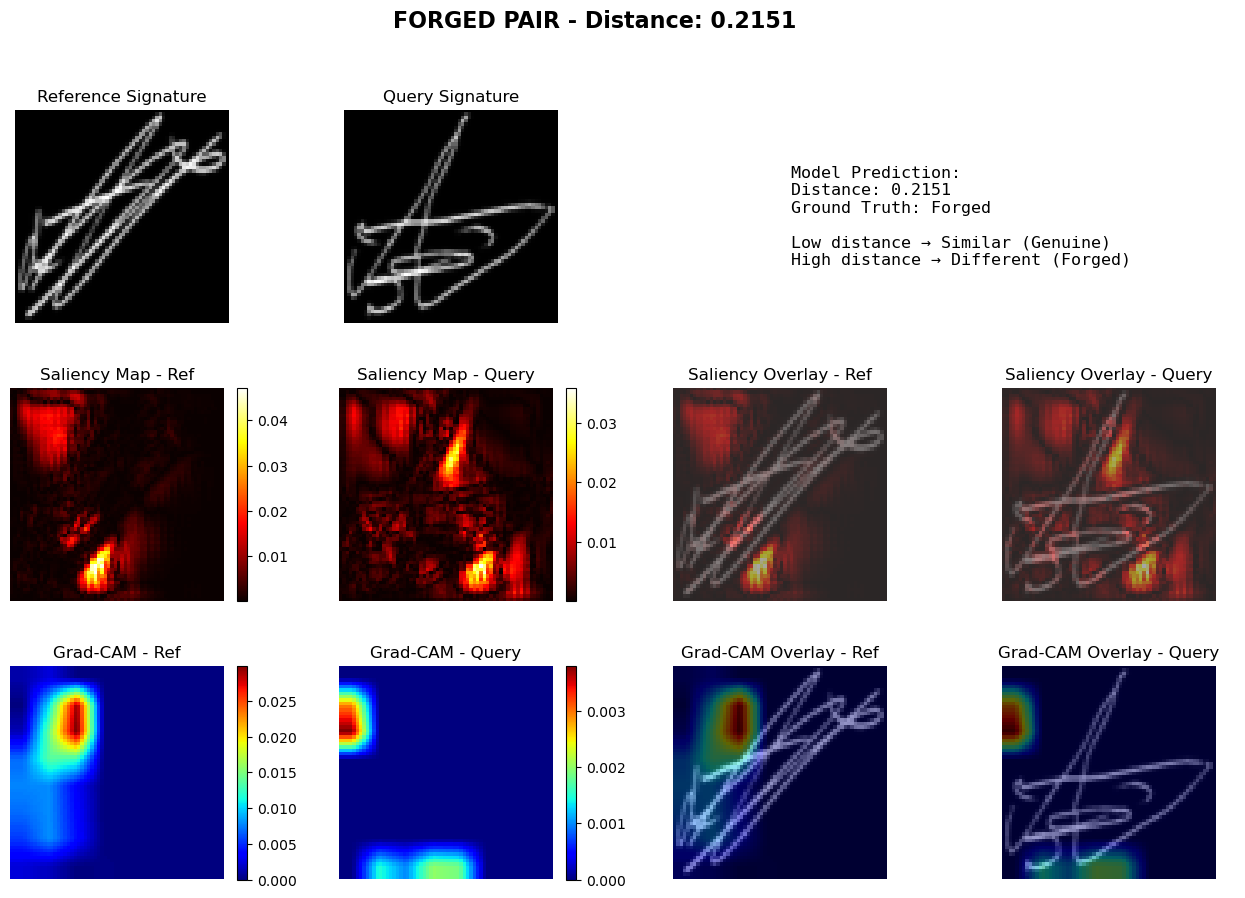


Pair 2: True=0.0, Predicted=1.0, Distance=0.2735
Saved: wrong_predictions/pair_2_forged pair_dist0.274.png


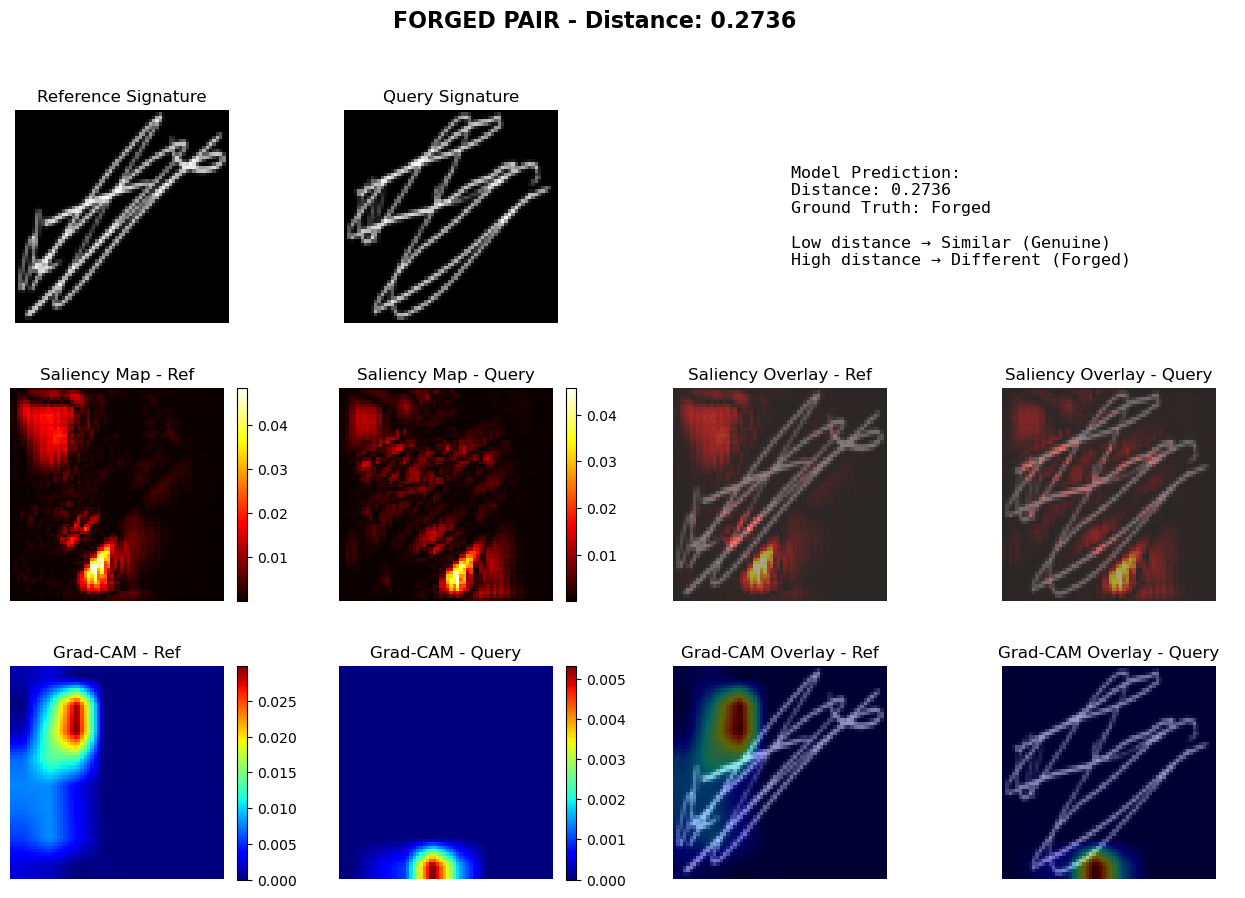


Pair 3: True=0.0, Predicted=1.0, Distance=0.3369
Saved: wrong_predictions/pair_3_forged pair_dist0.337.png


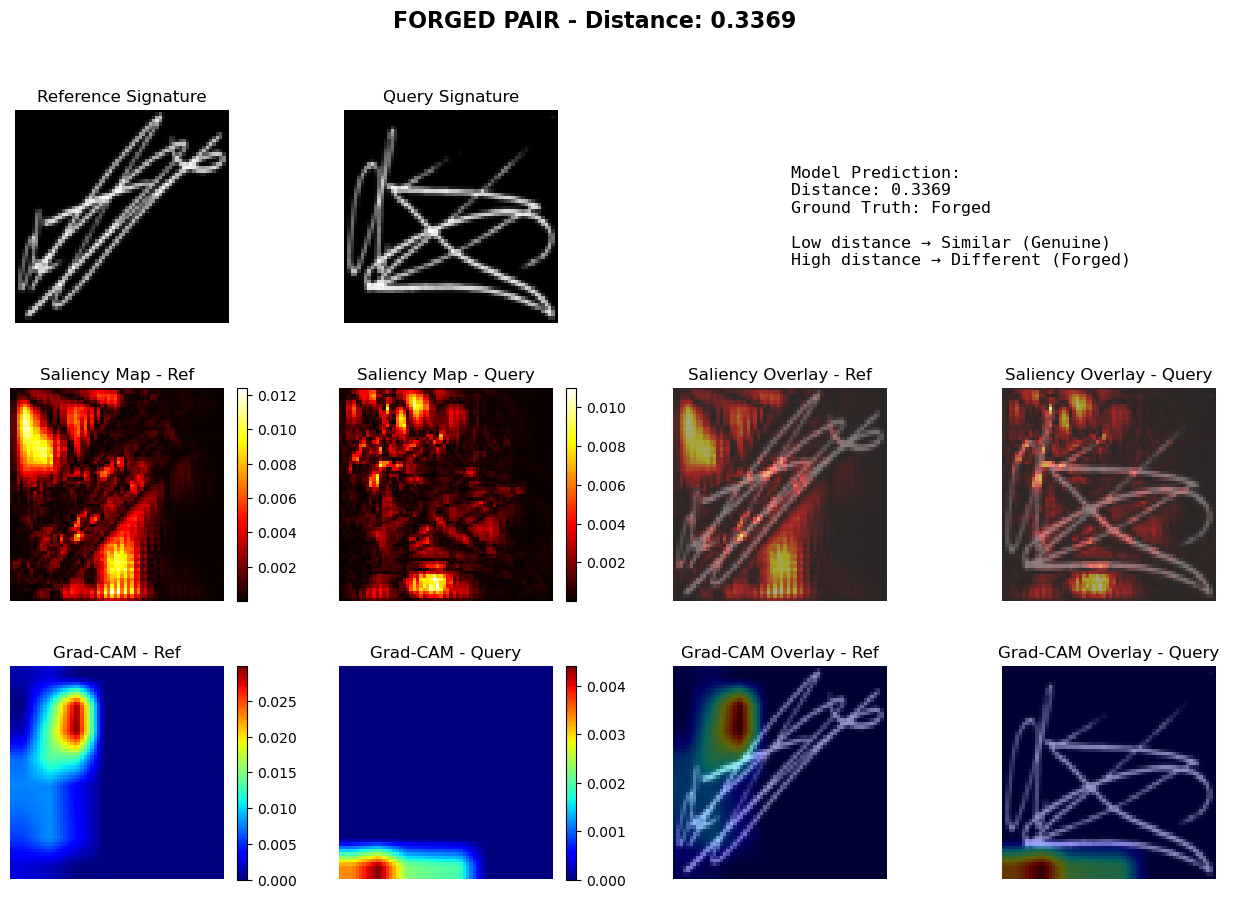


Pair 4: True=0.0, Predicted=1.0, Distance=0.3513
Saved: wrong_predictions/pair_4_forged pair_dist0.351.png


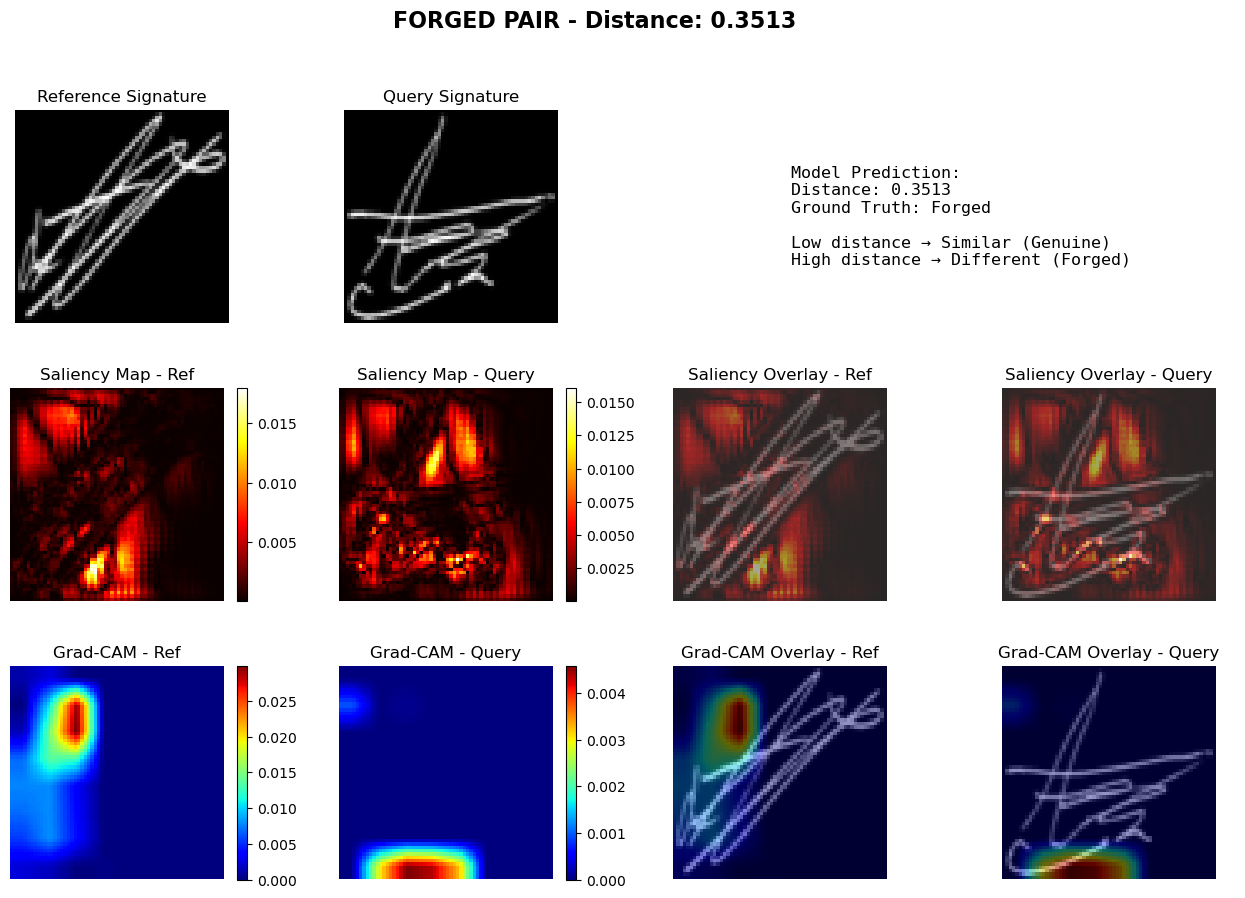


Pair 5: True=0.0, Predicted=1.0, Distance=0.2185
Saved: wrong_predictions/pair_5_forged pair_dist0.219.png


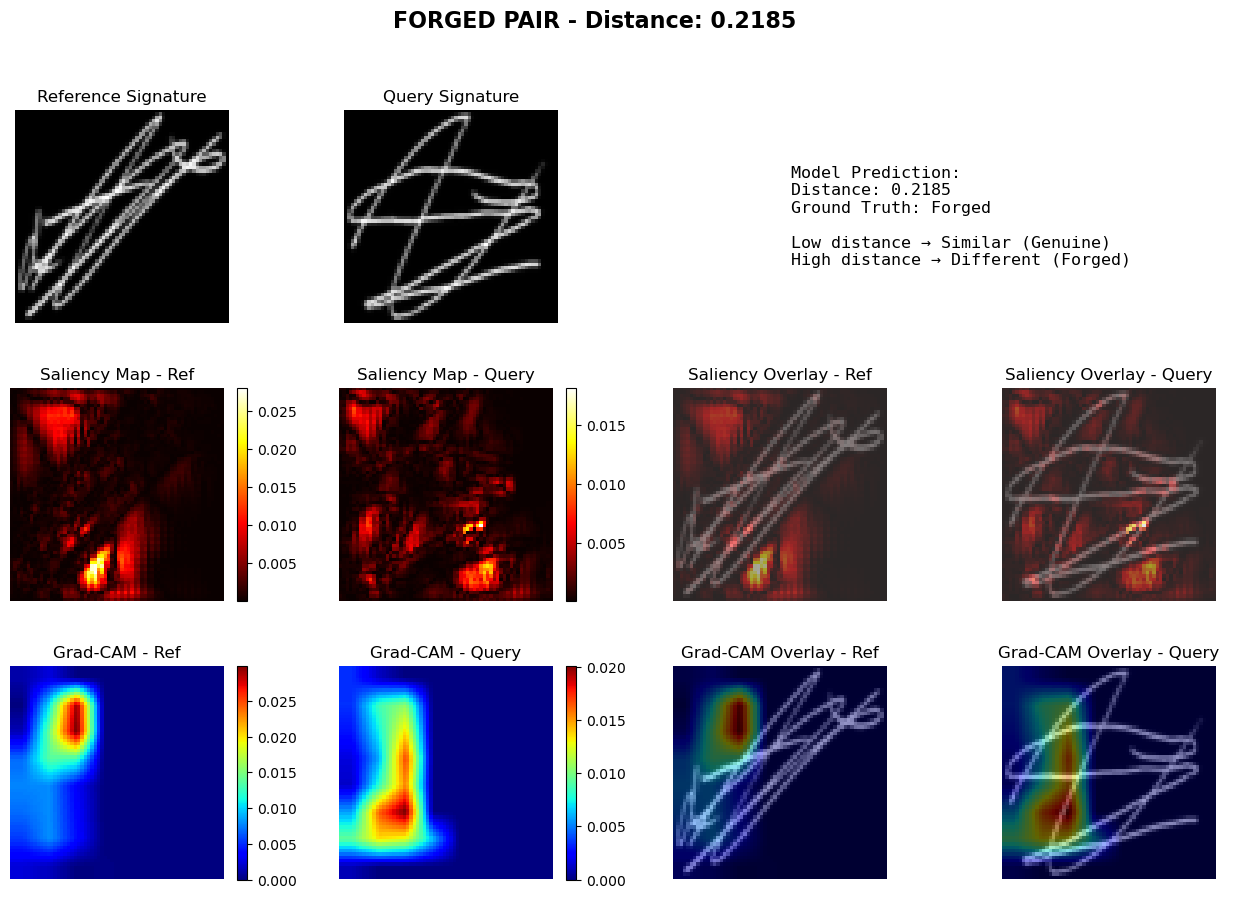


Pair 6: True=0.0, Predicted=1.0, Distance=0.3754
Saved: wrong_predictions/pair_6_forged pair_dist0.375.png


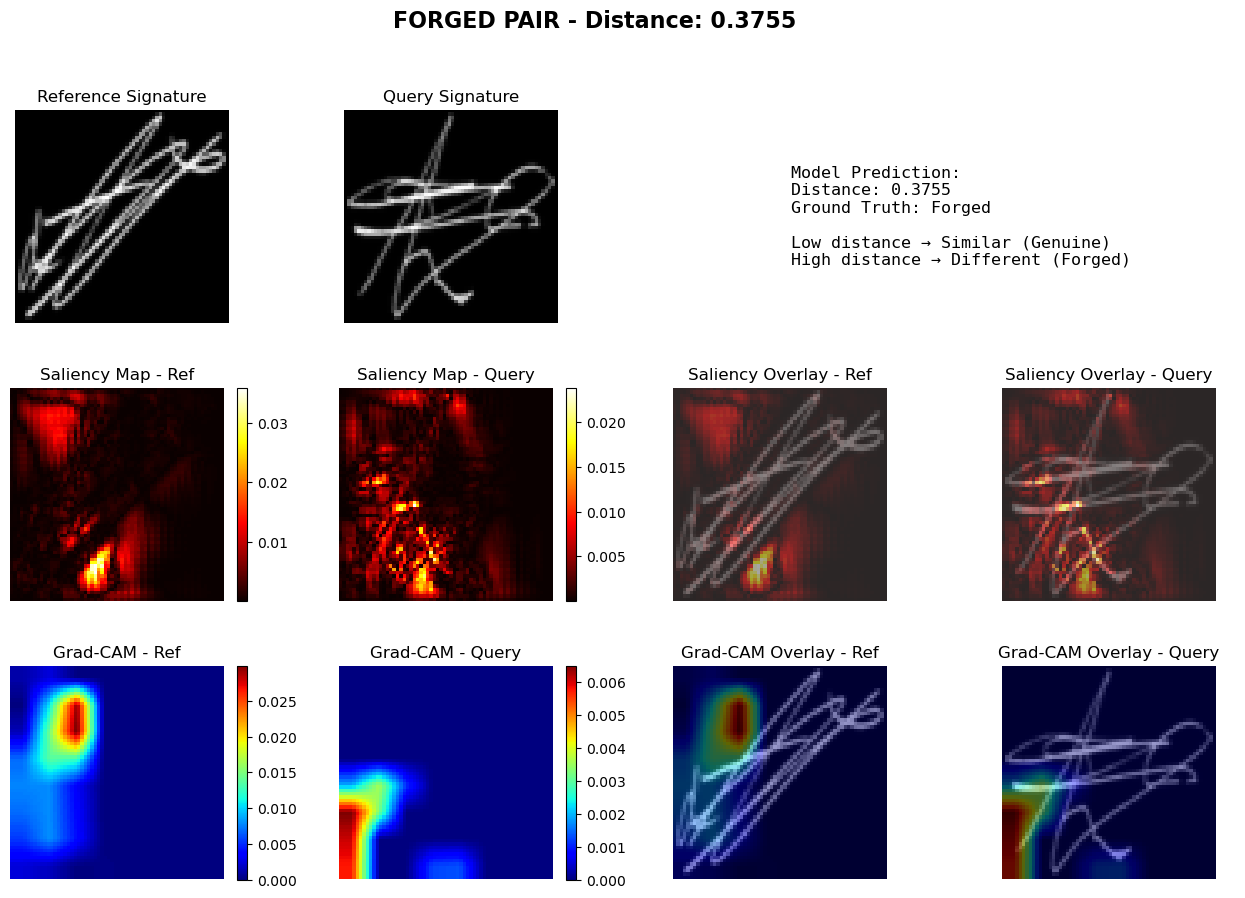


Pair 7: True=0.0, Predicted=1.0, Distance=0.2098
Saved: wrong_predictions/pair_7_forged pair_dist0.210.png


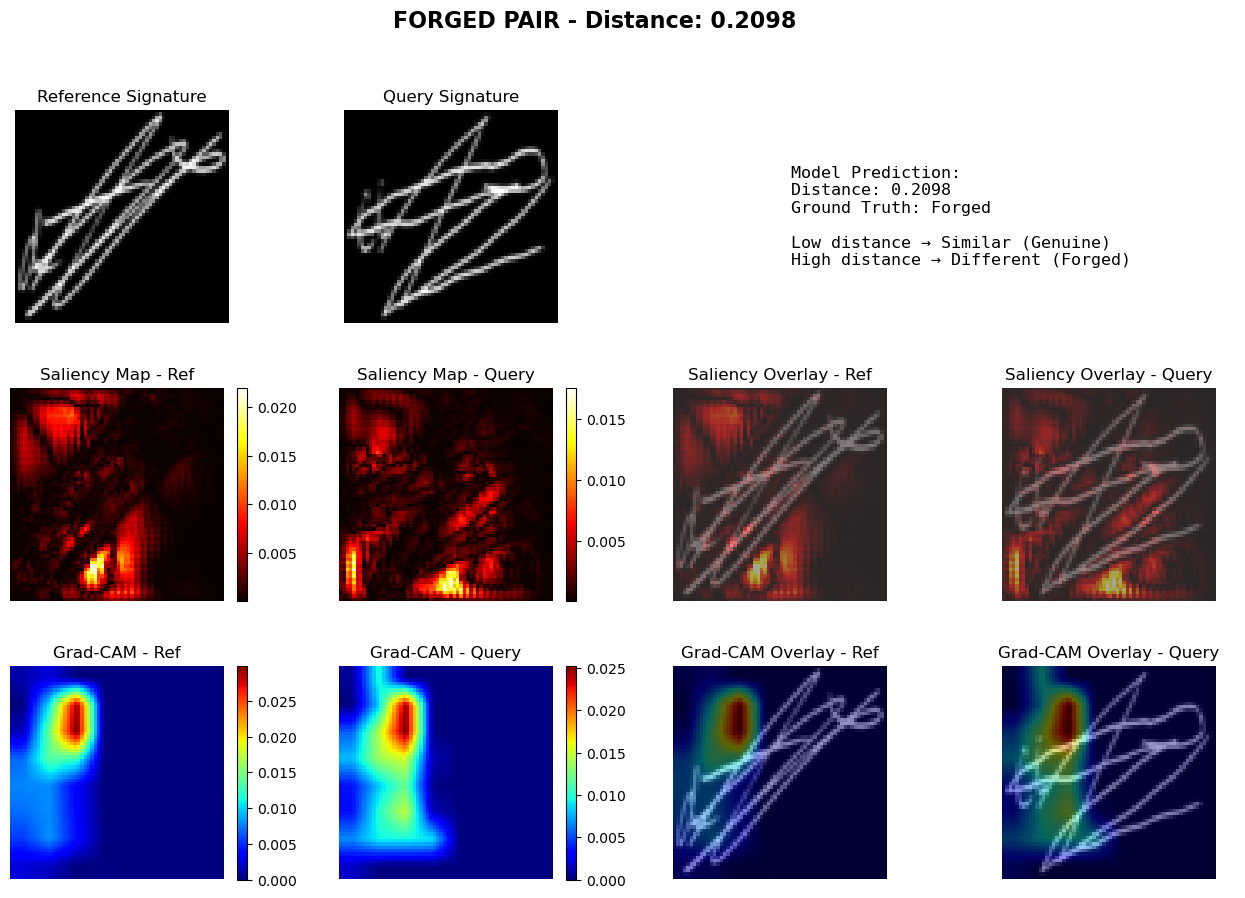


Pair 8: True=0.0, Predicted=1.0, Distance=0.2058
Saved: wrong_predictions/pair_8_forged pair_dist0.206.png


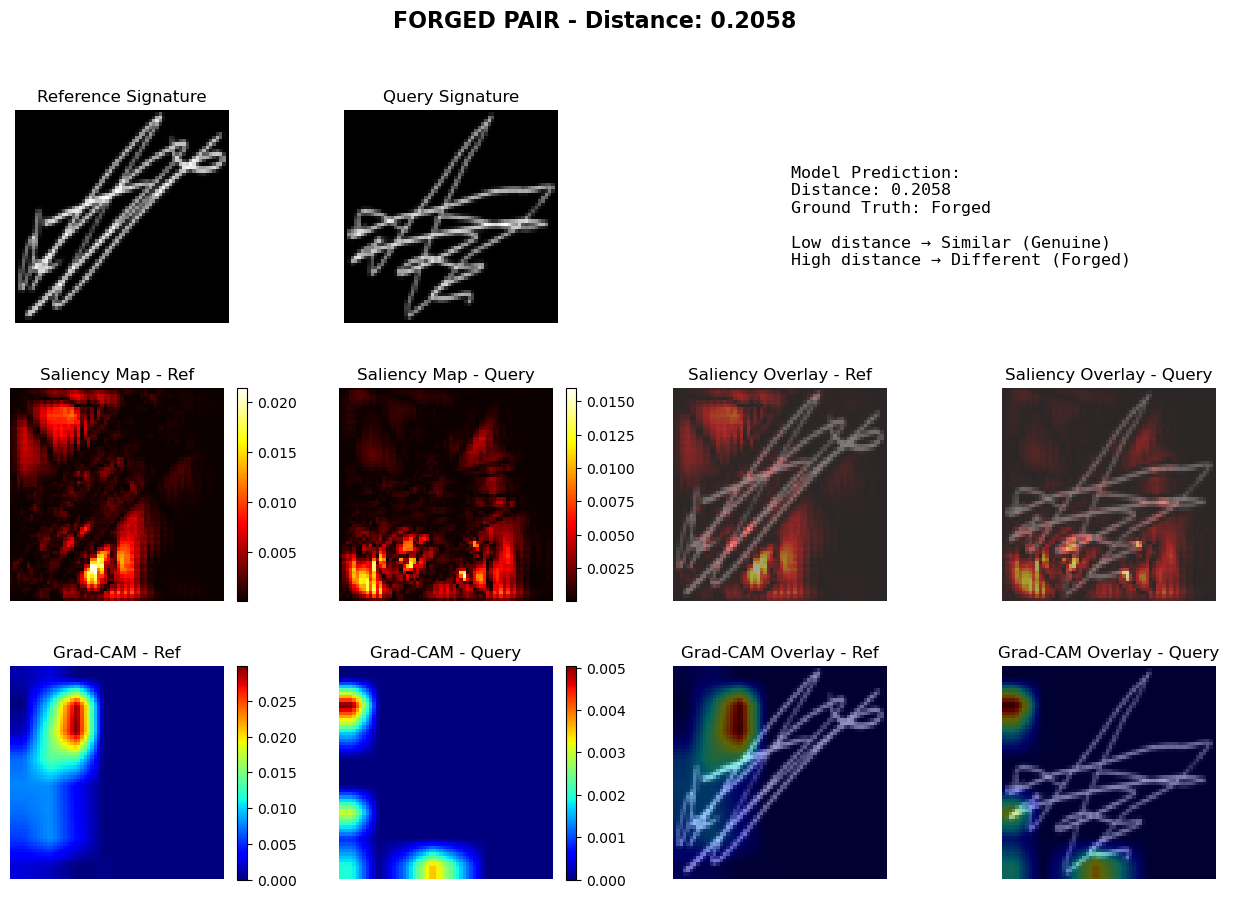


Pair 9: True=0.0, Predicted=1.0, Distance=0.2002
Saved: wrong_predictions/pair_9_forged pair_dist0.200.png


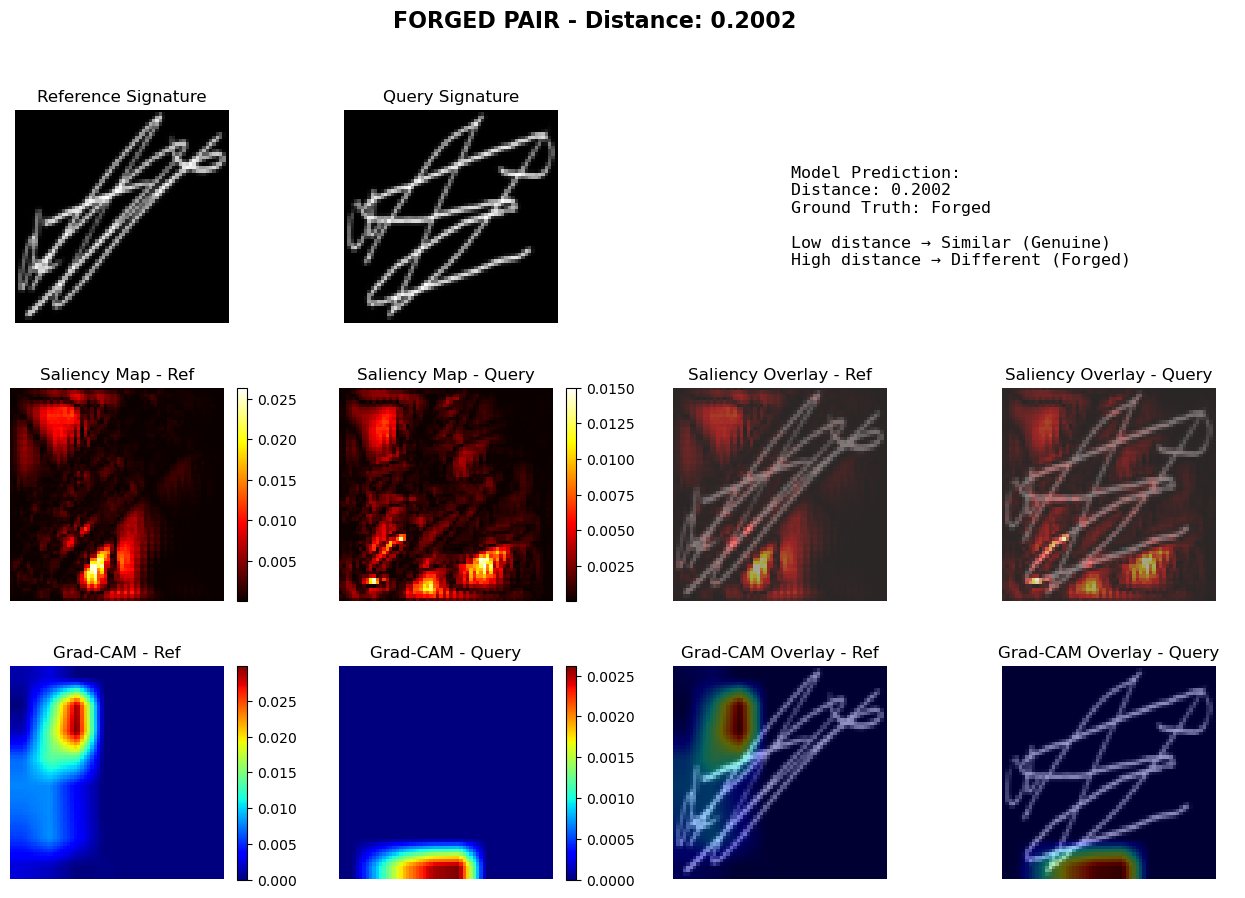

ModuleNotFoundError: No module named 'tqdm'

In [66]:
# ==============================================================================
# ADD THESE CELLS TO YOUR NOTEBOOK - SALIENCY MAP ANALYSIS
# ==============================================================================

# ─── Cell 1: Import the visualization module ──────────────────────────────
import saliency_visualization
importlib.reload(saliency_visualization)
from saliency_visualization import SaliencyVisualizer, analyze_model_focus

# ─── Cell 2: Run comprehensive analysis ───────────────────────────────────
# Load your best model
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

# # Analyze what the model is learning
# print("Starting saliency map analysis...")
# analyze_model_focus(
#     model=model,
#     dataloader=testdataloader,  # or val_loader for validation set
#     device=device,
#     num_samples=10,  # Visualize 10 genuine + 10 forged pairs
#     save_dir='saliency_outputs'
# )

# ─── Cell 3: Analyze specific problematic pairs ───────────────────────────
"""
If you want to visualize specific pairs (e.g., misclassified ones),
use this cell to manually select pairs
"""

visualizer = SaliencyVisualizer(model, device)

# Get a batch from your testdataloader
for img1_array, img2, labels in test_dataloader:
    # Use first reference if multiple
    if isinstance(img1_array, list):
        img1 = img1_array[0]
    else:
        img1 = img1_array
    
    # Visualize first 5 pairs in this batch
    for i in range(min(5, len(labels))):
        visualizer.visualize_pair(
            img1[i:i+1], 
            img2[i:i+1], 
            labels[i].item(),
            save_path='manual_analysis',
            pair_idx=i
        )
    
    break  # Only process first batch

# ─── Cell 4: Feature map visualization ────────────────────────────────────
"""
Visualize what intermediate layers are learning
"""

visualizer = SaliencyVisualizer(model, device)

# Get a single image
for img1_array, img2, labels in test_dataloader:
    if isinstance(img1_array, list):
        img1 = img1_array[0][0:1]  # First reference of first sample
    else:
        img1 = img1_array[0:1]
    
    # Visualize feature maps at different layers
    visualizer.visualize_feature_maps(
        img1,
        save_path='feature_map_analysis',
        img_idx=0
    )
    
    break

# ─── Cell 5: Compare model predictions with visualizations ────────────────
"""
Analyze cases where model is confident but wrong
"""

visualizer = SaliencyVisualizer(model, device)
model.eval()

confident_wrong_pairs = []

with torch.no_grad():
    for img1_array, img2, labels in test_dataloader:
        # Handle reference images
        if isinstance(img1_array, list):
            img1_batch = torch.stack(img1_array).to(device, non_blocking=True)
            N, B, C, H, W = img1_batch.shape
            img1_flat = img1_batch.reshape(N * B, C, H, W)
            emb1_flat = model(img1_flat)
            emb1 = emb1_flat.reshape(N, B, -1).mean(dim=0)
        else:
            img1 = img1_array.to(device, non_blocking=True)
            emb1 = model(img1)
        
        img2 = img2.to(device, non_blocking=True)
        emb2 = model(img2)
        
        distances = F.pairwise_distance(emb1, emb2)
        
        # Find confident wrong predictions
        threshold = optimal_threshold  # Use your optimal threshold
        predictions = (distances < threshold).float()
        
        for i in range(len(labels)):
            is_wrong = (predictions[i] != labels[i])
            confidence = abs(distances[i].item() - threshold)
            
            if is_wrong and confidence > 0.1:  # Confidently wrong
                if isinstance(img1_array, list):
                    img1_single = img1_array[0][i:i+1]
                else:
                    img1_single = img1_array[i:i+1]
                
                confident_wrong_pairs.append({
                    'img1': img1_single,
                    'img2': img2[i:i+1],
                    'label': labels[i].item(),
                    'distance': distances[i].item(),
                    'predicted': predictions[i].item()
                })
                
                if len(confident_wrong_pairs) >= 10:
                    break
        
        if len(confident_wrong_pairs) >= 10:
            break

# Visualize confident wrong predictions
print(f"\nFound {len(confident_wrong_pairs)} confidently wrong predictions")
print("These are the cases where the model is most confused:")

for idx, pair in enumerate(confident_wrong_pairs):
    print(f"\nPair {idx}: True={pair['label']}, Predicted={pair['predicted']}, Distance={pair['distance']:.4f}")
    visualizer.visualize_pair(
        pair['img1'],
        pair['img2'],
        pair['label'],
        save_path='wrong_predictions',
        pair_idx=idx
    )

# ─── Cell 6: Statistical analysis of saliency patterns ────────────────────
"""
Quantify where the model is focusing across many samples
"""

import numpy as np
from tqdm import tqdm

visualizer = SaliencyVisualizer(model, device)

genuine_saliency_maps = []
forged_saliency_maps = []

# Collect saliency maps
num_analyze = 100  # Analyze 100 pairs of each type

with torch.no_grad():
    genuine_count = 0
    forged_count = 0
    
    for img1_array, img2, labels in tqdm(test_dataloader, desc="Computing saliency maps"):
        if isinstance(img1_array, list):
            img1 = img1_array[0]
        else:
            img1 = img1_array
        
        for i in range(len(labels)):
            if genuine_count >= num_analyze and forged_count >= num_analyze:
                break
            
            img1_single = img1[i:i+1]
            img2_single = img2[i:i+1]
            label = labels[i].item()
            
            try:
                sal1, sal2, dist = visualizer.compute_saliency(img1_single, img2_single, label)
                avg_sal = (sal1 + sal2) / 2
                
                if label == 1 and genuine_count < num_analyze:
                    genuine_saliency_maps.append(avg_sal)
                    genuine_count += 1
                elif label == 0 and forged_count < num_analyze:
                    forged_saliency_maps.append(avg_sal)
                    forged_count += 1
            except:
                continue
        
        if genuine_count >= num_analyze and forged_count >= num_analyze:
            break

# Compute average saliency maps
genuine_avg = np.mean(genuine_saliency_maps, axis=0)
forged_avg = np.mean(forged_saliency_maps, axis=0)

# Visualize average focus patterns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].imshow(genuine_avg, cmap='hot')
axes[0].set_title(f'Average Focus: Genuine Pairs (n={len(genuine_saliency_maps)})')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(forged_avg, cmap='hot')
axes[1].set_title(f'Average Focus: Forged Pairs (n={len(forged_saliency_maps)})')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1])

# Difference map
difference = genuine_avg - forged_avg
im2 = axes[2].imshow(difference, cmap='RdBu', vmin=-difference.max(), vmax=difference.max())
axes[2].set_title('Difference (Genuine - Forged)')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.savefig('average_saliency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Compute focus statistics
def compute_focus_stats(saliency_maps):
    """Compute where the model focuses (center vs edges)"""
    center_vals = []
    edge_vals = []
    
    for sal in saliency_maps:
        h, w = sal.shape
        center_mask = np.zeros_like(sal)
        center_mask[h//4:3*h//4, w//4:3*w//4] = 1
        
        center_vals.append(sal[center_mask == 1].mean())
        edge_vals.append(sal[center_mask == 0].mean())
    
    return {
        'center_mean': np.mean(center_vals),
        'edge_mean': np.mean(edge_vals),
        'center_to_edge_ratio': np.mean(center_vals) / (np.mean(edge_vals) + 1e-8)
    }

genuine_stats = compute_focus_stats(genuine_saliency_maps)
forged_stats = compute_focus_stats(forged_saliency_maps)

print("\n" + "="*60)
print("FOCUS STATISTICS")
print("="*60)
print("\nGenuine Pairs:")
print(f"  Center focus: {genuine_stats['center_mean']:.4f}")
print(f"  Edge focus: {genuine_stats['edge_mean']:.4f}")
print(f"  Center/Edge ratio: {genuine_stats['center_to_edge_ratio']:.2f}")

print("\nForged Pairs:")
print(f"  Center focus: {forged_stats['center_mean']:.4f}")
print(f"  Edge focus: {forged_stats['edge_mean']:.4f}")
print(f"  Center/Edge ratio: {forged_stats['center_to_edge_ratio']:.2f}")

print("\n" + "="*60)
print("INTERPRETATION:")
print("="*60)
print("""
✓ Center/Edge ratio > 2.0: Model focuses on signature content (GOOD)
✗ Center/Edge ratio < 1.5: Model may be learning image artifacts (BAD)

✓ Similar ratios for genuine/forged: Consistent behavior (GOOD)
✗ Very different ratios: Model uses different strategies (investigate)
""")

Validation Accuracy (optimal threshold=0.295): 0.7058
Accuracy:  0.7058
Precision: 0.6719
Recall:    0.7590
F1-score:  0.7128
AUC:       0.7803

Distance Statistics:
  Genuine mean: 0.211 ± 0.149
  Forged mean:  0.451 ± 0.278


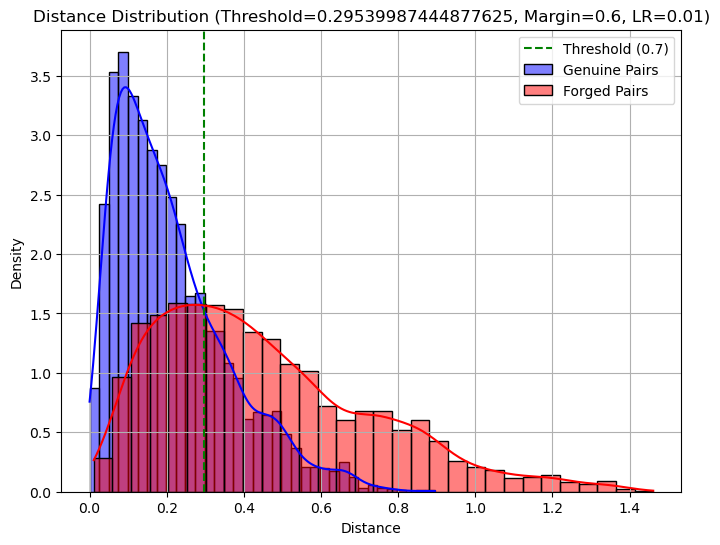

In [23]:
val_losses = []
distance_all = []
labels_all = []
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()
with torch.no_grad():
    for img1_array, img2, labels in test_dataloader:
        # Use only first reference
        img1 = img1_array.to(device, non_blocking=True)
        #img1 = img1_array.to(device, non_blocking=True)
        img2 = img2.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
    
        with autocast("cuda", dtype=torch.bfloat16):
            emb1 = model(img1)
            emb2 = model(img2)
    
        distance = F.pairwise_distance(emb1, emb2)
        distance_all.append(distance)
        labels_all.append(labels)
    
        val_batch_loss = criterion(emb1, emb2, labels)
        val_losses.append(val_batch_loss.item())

# Aggregate
distance_all = torch.cat(distance_all)
labels_all = torch.cat(labels_all)
avg_val_loss = sum(val_losses) / len(val_losses)

# ─── Threshold tuning (FIXED!) ───────────────────────────────
y_true = labels_all.cpu().numpy()  # ← THIS WAS MISSING!

# Method 1: Simple negation approach (recommended)
similarity_scores = -distance_all.cpu().numpy()
fpr, tpr, thresholds_roc = roc_curve(y_true, similarity_scores)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = -thresholds_roc[optimal_idx]  # Convert back to distance

y_pred = (distance_all.cpu().numpy() < optimal_threshold).astype(int)
y_pred_optimal = (distance_all.cpu().numpy() < optimal_threshold).astype(int)

print(f"Validation Accuracy (optimal threshold={optimal_threshold:.3f}): {accuracy_score(y_true, y_pred_optimal):.4f}")
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
print(f"AUC:       {roc_auc_score(y_true, similarity_scores):.4f}")
print(f"\nDistance Statistics:")
print(f"  Genuine mean: {distance_all[labels_all==1].mean():.3f} ± {distance_all[labels_all==1].std():.3f}")
print(f"  Forged mean:  {distance_all[labels_all==0].mean():.3f} ± {distance_all[labels_all==0].std():.3f}")
indices = np.random.permutation(len(labels_all))
distance_np = distance_all[indices].cpu().numpy()
labels_np = labels_all[indices].cpu().numpy()
distance_genuine = distance_np[labels_np == 1].tolist()
distance_forged = distance_np[labels_np == 0].tolist()

plt.figure(figsize=(8, 6))
sns.histplot(distance_genuine, color='blue', label='Genuine Pairs', kde=True, stat='density')
sns.histplot(distance_forged, color='red', label='Forged Pairs', kde=True, stat='density')
plt.axvline(x=optimal_threshold, color='green', linestyle='--', label=f'Threshold ({threshold})')
plt.xlabel('Distance')
plt.ylabel('Density')
plt.title(f'Distance Distribution (Threshold={optimal_threshold}, Margin={margin}, LR={lr})')
plt.legend()
plt.grid(True)
# plt.savefig(f"second_saved_models/saved_models/LENET/cosine_sim/cosine_similarity_distribution_threshold_{threshold}_{margin}_{lr}.png")
plt.show()  # Display the plot
plt.close()

Validation Accuracy (optimal threshold=0.253): 0.5243
Accuracy:  0.6175
Precision: 0.6463
Recall:    0.5606
F1-score:  0.6004
AUC:       0.6411
0.789


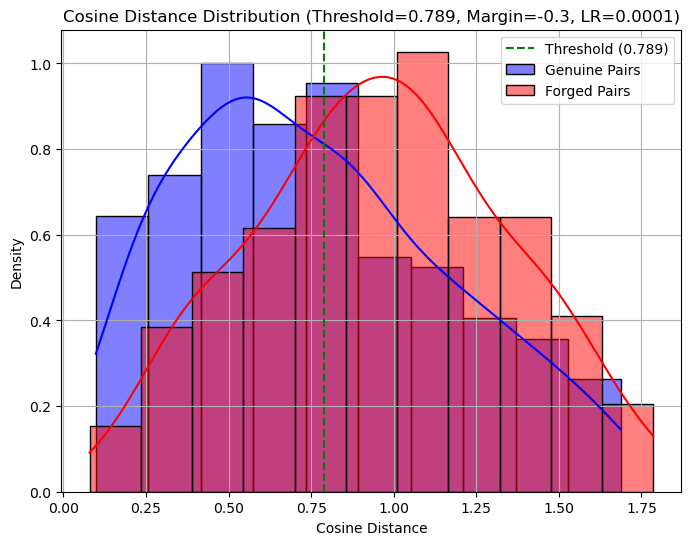

In [47]:
# model_path = f"second_saved_models/savedmodels/dropoutCNN/siamese_margin{margin}_size64_dropout4_lr{lr}.pt"
# model.load_state_dict(torch.load(model_path, map_location=device))
# torch.cuda.empty_cache()  # Clears GPU cache in PyTorch
#model.eval()
correct = 0
total = 0
cosine_sim_all = []
labels_all = []
with torch.no_grad():
    for img1_array, img2, labels in val_loader:
        emb1_array=[]
        for img1 in img1_array:
            img1 = img1.to(device, non_blocking=True)
            with autocast("cuda", dtype=torch.bfloat16):
                emb1 = model(img1)
                emb1_array.append(emb1)
        emb1=torch.cat(emb1_array,dim=0).mean(dim=0,keepdim=True)
        
        img2 = img2.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with autocast("cuda", dtype=torch.bfloat16):
            emb2 = model(img2)
            
        cosine_sim = F.cosine_similarity(emb1, emb2)
        cosine_sim= (1-cosine_sim)
        cosine_sim_all.append(cosine_sim)
        labels_all.append(labels)
        total += labels.size(0)

    
    cosine_sim_all = torch.cat(cosine_sim_all)
    labels_all = torch.cat(labels_all)
    y_true = labels_all.cpu().numpy()
    y_pred = (cosine_sim_all.cpu().numpy() < threshold).astype(int)

    fpr, tpr, thresholds = roc_curve(y_true, 1 - cosine_sim_all.cpu().numpy())
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]

    y_pred_optimal = (cosine_sim_all.cpu().numpy() < optimal_threshold).astype(int)
    print(f"Validation Accuracy (optimal threshold={optimal_threshold:.3f}): {accuracy_score(y_true, y_pred_optimal):.4f}")
    
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
    print(f"AUC:       {roc_auc_score(y_true, 1-cosine_sim_all.cpu().numpy()):.4f}")
    print(threshold)
    # Histogram
    indices = np.random.permutation(len(labels_all))
    cosine_sim_np = cosine_sim_all[indices].cpu().numpy()
    labels_np = labels_all[indices].cpu().numpy()
    cosine_sim_genuine = cosine_sim_np[labels_np == 1].tolist()
    cosine_sim_forged = cosine_sim_np[labels_np == 0].tolist()
    
    plt.figure(figsize=(8, 6))
    sns.histplot(cosine_sim_genuine, color='blue', label='Genuine Pairs', kde=True, stat='density')
    sns.histplot(cosine_sim_forged, color='red', label='Forged Pairs', kde=True, stat='density')
    plt.axvline(x=threshold, color='green', linestyle='--', label=f'Threshold ({threshold})')
    plt.xlabel('Cosine Distance')
    plt.ylabel('Density')
    plt.title(f'Cosine Distance Distribution (Threshold={threshold}, Margin={margin}, LR={lr})')
    plt.legend()
    plt.grid(True)
    # plt.savefig(f"second_saved_models/saved_models/LENET/cosine_sim/cosine_similarity_distribution_threshold_{threshold}_{margin}_{lr}.png")
    plt.show()  # Display the plot
    plt.close()


W0128 19:47:04.403000 20168 site-packages\torch\_inductor\utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode
C:\Users\gupta\AppData\Local\Temp\ipykernel_20168\1064687217.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  emb1=torch.tensor(emb1)


Accuracy:  0.5000
Precision: 0.3333
Recall:    0.6000
F1-score:  0.4286
AUC:       0.5636


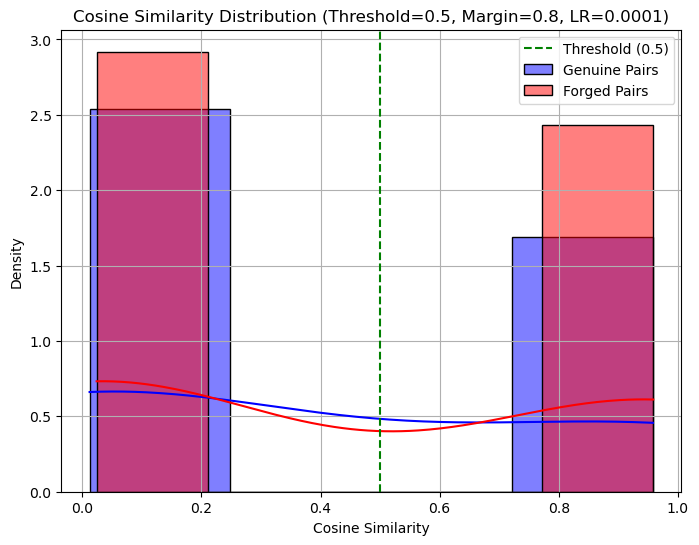

In [11]:
# model_path = f"second_saved_models/savedmodels/dropoutCNN/siamese_margin{margin}_size64_dropout4_lr{lr}.pt"
# model.load_state_dict(torch.load(model_path, map_location=device))
# # torch.cuda.empty_cache()  # Clears GPU cache in PyTorch
# model.eval()
# correct = 0
# total = 0
# cosine_sim_all = []
# labels_all = []
# emb1_array=[]
# with torch.no_grad():
#     for img1_array, img2, labels in val_loader:
#         for img1 in img1_array:
#             img1 = img1.to(device, non_blocking=True)
#             with autocast("cuda", dtype=torch.bfloat16):
#                 emb1 = model(img1)
#                 emb1_array.append(emb1)
#         emb1=torch.tensor(emb1)
#         emb1=torch.cat(emb1_array,dim=0).mean(dim=0)
        
#         img2 = img2.to(device, non_blocking=True)
#         labels = labels.to(device, non_blocking=True)
#         with autocast("cuda", dtype=torch.bfloat16):
#             emb2 = model(img2)
            
#         cosine_sim = F.cosine_similarity(emb1, emb2)
#         # cosine_sim=F.normalize(cosine_sim)
#         # cosine_sim=F.pairwise_distance(emb1, emb2)
#         cosine_sim= (1-cosine_sim)/2
#     cosine_sim_all.append(cosine_sim)
#     labels_all.append(labels)
#     # predictions = (cosine_sim < threshold).float()
#     # correct += (predictions == labels).sum().item()
#     total += labels.size(0)

    
#     cosine_sim_all = torch.cat(cosine_sim_all)
# labels_all = torch.cat(labels_all)
# y_true = labels_all.cpu().numpy()
# y_pred = (cosine_sim_all.cpu().numpy() < threshold).astype(int)

# print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
# print(f"Precision: {precision_score(y_true, y_pred):.4f}")
# print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
# print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
# print(f"AUC:       {roc_auc_score(y_true, 1 - cosine_sim_all.cpu().numpy()):.4f}")

# # Histogram
# indices = np.random.permutation(total)[:1000]
# cosine_sim_np = cosine_sim_all[indices].cpu().numpy()
# labels_np = labels_all[indices].cpu().numpy()
# cosine_sim_genuine = cosine_sim_np[labels_np == 1].tolist()
# cosine_sim_forged = cosine_sim_np[labels_np == 0].tolist()

# plt.figure(figsize=(8, 6))
# sns.histplot(cosine_sim_genuine, color='blue', label='Genuine Pairs', kde=True, stat='density')
# sns.histplot(cosine_sim_forged, color='red', label='Forged Pairs', kde=True, stat='density')
# plt.axvline(x=threshold, color='green', linestyle='--', label=f'Threshold ({threshold})')
# plt.xlabel('Cosine Similarity')
# plt.ylabel('Density')
# plt.title(f'Cosine Similarity Distribution (Threshold={threshold}, Margin={margin}, LR={lr})')
# plt.legend()
# plt.grid(True)
# # plt.savefig(f"second_saved_models/saved_models/LENET/cosine_sim/cosine_similarity_distribution_threshold_{threshold}_{margin}_{lr}.png")
# plt.show()  # Display the plot
# plt.close()


In [ ]:
# # Load the model
# model = SiameseCNN().to(device)
# try:
#     model.load_state_dict(torch.load(PATH, map_location=device))
# except RuntimeError as e:
#     print(f"Error loading model: {e}")


In [ ]:
genuine_count = 0
forged_count = 0
total_samples = 0
for img1, img2, labels in dataloader:
    genuine_count += (labels == 1).sum().item()
    forged_count += (labels == 0).sum().item()
    total_samples += labels.size(0)
print(f"Genuine: {genuine_count} ({genuine_count / total_samples * 100:.2f}%), Forged: {forged_count} ({forged_count / total_samples * 100:.2f}%)")

In [ ]:
def evaluate_accuracy(model, testdataloader, margin, lr, threshold=0.5, device="cuda"):
    torch.cuda.empty_cache()  # Clears GPU cache in PyTorch
    model.eval()
    correct = 0
    total = 0
    cosine_sim_all = []
    labels_all = []
    
    with torch.no_grad():
        for img1, img2, labels in testdataloader:
            img1 = img1.to(device, non_blocking=True)
            img2 = img2.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            try:
                with autocast():
                    emb1 = model(img1)
                    emb2 = model(img2)
                    emb1 = F.normalize(emb1, p=2, dim=1)
                    emb2 = F.normalize(emb2, p=2, dim=1)
                    cosine_sim = F.cosine_similarity(emb1, emb2)
                cosine_sim_all.append(cosine_sim)
                labels_all.append(labels)
                predictions = (cosine_sim > threshold).float()
                correct += (predictions == labels).sum().item()
                total += labels.size(0)
            except RuntimeError as e:
                print(f"Error in evaluation: {e}")
                if "out of memory" in str(e):
                    torch.cuda.empty_cache()
                    continue

    cosine_sim_all = torch.cat(cosine_sim_all)
    labels_all = torch.cat(labels_all)

    # Histogram
    indices = np.random.permutation(total)[:1000]
    cosine_sim_np = cosine_sim_all[indices].cpu().numpy()
    labels_np = labels_all[indices].cpu().numpy()
    cosine_sim_genuine = cosine_sim_np[labels_np == 1].tolist()
    cosine_sim_forged = cosine_sim_np[labels_np == 0].tolist()

    plt.figure(figsize=(8, 6))
    sns.histplot(cosine_sim_genuine, color='blue', label='Genuine Pairs', kde=True, stat='density')
    sns.histplot(cosine_sim_forged, color='red', label='Forged Pairs', kde=True, stat='density')
    plt.axvline(x=threshold, color='green', linestyle='--', label=f'Threshold ({threshold})')
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Density')
    plt.title(f'Cosine Similarity Distribution (Threshold={threshold}, Margin={margin}, LR={lr})')
    plt.legend()
    plt.grid(True)
    plt.savefig(f"saved_models/LENET/cosine_similarity_distribution_threshold_{threshold}_{margin}_{lr}.png")
    plt.show()  # Display the plot
    plt.close()

    # Confusion Matrix
    predictions = (cosine_sim_all > threshold).float()
    cm = confusion_matrix(labels_all.cpu(), predictions.cpu())
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Forged', 'Genuine'], yticklabels=['Forged', 'Genuine'])
    plt.title(f'Confusion Matrix (Threshold={threshold}, Margin={margin}, LR={lr})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(f"saved_models/LENET/confusion_matrix_threshold_{threshold}_{margin}_{lr}.png")
    plt.show()  # Display the plot
    plt.close()

    # ROC Curve
    fpr, tpr, _ = roc_curve(labels_all.cpu(), cosine_sim_all.cpu())
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve (Threshold={threshold}, Margin={margin}, LR={lr})')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.savefig(f"saved_models/LENET/roc_curve_threshold_{threshold}_{margin}_{lr}.png")
    plt.show()  # Display the plot
    plt.close()

    # Metrics
    accuracy = correct / total if total > 0 else 0.0
    precision, recall, f1, _ = precision_recall_fscore_support(labels_all.cpu(), predictions.cpu(), average='binary')
    print(f"Threshold: {threshold}, Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, AUC: {roc_auc:.4f}")
    
    return accuracy

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SiameseCNN().to(device)  # Initialize model outside the loop
thresholds = [0.93]

# Load and evaluate models
for filename in os.listdir('./saved_models/LENET/'):
    if filename.endswith('.pt'):
        PATH = os.path.join('./saved_models/LENET', filename)
        parts = filename.split('_')
        margin = parts[1]  # e.g., 'margin0.5'
        lr = parts[2].replace('.pt', '')  # e.g., 'lr0.001'
        print(f"Attempting to load model: {filename}")
        print(margin,lr)
        if(margin=='margin0.8size256' and lr=="lr0.005"):
            try:
                model.load_state_dict(torch.load(PATH, map_location=device))
                print(f"Successfully loaded model from {PATH}")
                for thresh in thresholds:
                    accuracy = evaluate_accuracy(model, testdataloader, margin, lr, threshold=thresh, device=device)
                    print(f"Model: {filename}, Threshold: {thresh}, Accuracy: {accuracy:.4f}")
            except Exception as e:
                print(f"Error loading model {filename}: {e}")